In [1]:
import warnings;
warnings.simplefilter('ignore')
from dcr import *

In [2]:
%matplotlib inline
plt.rcParams['figure.dpi'] = 300
plt.rcParams['figure.figsize'] = (16,9)
plt.rcParams.update({'font.size': 16})

In [3]:
y_true = [1, 0, 1, 0, 0, 0] 
 
PD_pred =[0.07, 0.05, 0.04, 0.03, 0.02, 0.01] 
y_pred = np.asarray(PD_pred) >= 0.05  
print('y-pred:', y_pred) 
cm = confusion_matrix(y_true, y_pred)  
print('Confusion matrix:')  
print(cm) 

y-pred: [ True  True False False False False]
Confusion matrix:
[[3 1]
 [1 1]]


In [4]:
TN = cm[0,0]  
FP = cm[0,1]  
FN = cm[1,0]  
TP = cm[1,1]

In [5]:
Precision_0 = TN/(FN+TN)  
Precision_1 = TP/(TP+FP)  
print('Precision 0:', Precision_0)  
print('Precision 1:', Precision_1)

Precision 0: 0.75
Precision 1: 0.5


In [6]:
Recall_0 = TN/ (FP+TN)  
Recall_1 = TP/ (TP+FN)  
print('Recall 0:', Recall_0)  
print('Recall 1:', Recall_1)

Recall 0: 0.75
Recall 1: 0.5


In [7]:
F1score_0 = 2*TN/ (2*TN+FP+FN)  
F1score_1 = 2*TP/ (2*TP+FP+FN)  
print('F1score 0:', F1score_0)  
print('F1score 1:', F1score_1) 

F1score 0: 0.75
F1score 1: 0.5


In [8]:
support_0 = np.sum(np.asarray(y_true)==0)
support_1 = np.sum(np.asarray(y_true)==1)  
print('Support 0:', support_0) 
print('Support 1:', support_1)

Support 0: 4
Support 1: 2


In [9]:
accuracy = (TP+TN)/ (TP+TN+FP+FN)  
print('Accuracy:', accuracy.round(decimals=4))

Accuracy: 0.6667


In [10]:
Macro_precision = (Precision_0 + Precision_1)/2 
Weighted_precision = (Precision_0*support_0 + Precision_1*support_1)/len(y_true)  
print('Macro Precision:', Macro_precision)  
print('Weighted Precision:', Weighted_precision.round(decimals=4))

Macro Precision: 0.625
Weighted Precision: 0.6667


In [11]:
Macro_recall = (Recall_0 + Recall_1)/2  
Weighted_recall = (Recall_0 *support_0 + Recall_1*support_1)/len(y_true)  
print('Macro Recall:', Macro_recall)  
print('Weighted Recall:', Weighted_recall.round(decimals=4))

Macro Recall: 0.625
Weighted Recall: 0.6667


In [12]:
Macro_f1 = (F1score_0 + F1score_1)/2  
Weighted_f1 = (F1score_0 *support_0 + F1score_1*support_1)/len(y_true)  
print('Macro F1:', Macro_f1)  
print('Weighted F1:', Weighted_f1.round(decimals=4))

Macro F1: 0.625
Weighted F1: 0.6667


In [13]:
print('Classification Report:')  
print(classification_report(y_true, y_pred)) 

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.75      0.75         4
           1       0.50      0.50      0.50         2

    accuracy                           0.67         6
   macro avg       0.62      0.62      0.62         6
weighted avg       0.67      0.67      0.67         6



In [18]:
def sen(threshold):  
    global y_true  
    y_pred = np.asarray(PD_pred) >= threshold  
    print('Threshold:', threshold)  
    print('Default prediction:', y_pred) 
    cm = confusion_matrix(y_true, y_pred)  
    TN = cm[0,0]  
    TP = cm[1,1]  
    FP = cm[0,1]  
    FN = cm[1,0]  
    sensitivity = TP/(TP+FN)  
    one_min_specificity = 1-TN/(TN+FP)  
    return sensitivity, one_min_specificity

In [19]:
data_roc = np.array([0,0])  
for threshold in PD_pred: 
    result = sen(threshold) 
    data_roc = np.append(data_roc, np.asarray(result), axis=0)  
    
    print('Sen., 1-Spec.:', result)  
    
data_roc = data_roc.reshape(-1,2)  
print('Combined data:')  
print(data_roc) 

Threshold: 0.07
Default prediction: [ True False False False False False]
Sen., 1-Spec.: (0.5, 0.0)
Threshold: 0.05
Default prediction: [ True  True False False False False]
Sen., 1-Spec.: (0.5, 0.25)
Threshold: 0.04
Default prediction: [ True  True  True False False False]
Sen., 1-Spec.: (1.0, 0.25)
Threshold: 0.03
Default prediction: [ True  True  True  True False False]
Sen., 1-Spec.: (1.0, 0.5)
Threshold: 0.02
Default prediction: [ True  True  True  True  True False]
Sen., 1-Spec.: (1.0, 0.75)
Threshold: 0.01
Default prediction: [ True  True  True  True  True  True]
Sen., 1-Spec.: (1.0, 1.0)
Combined data:
[[0.   0.  ]
 [0.5  0.  ]
 [0.5  0.25]
 [1.   0.25]
 [1.   0.5 ]
 [1.   0.75]
 [1.   1.  ]]


(0.0, 1.1)

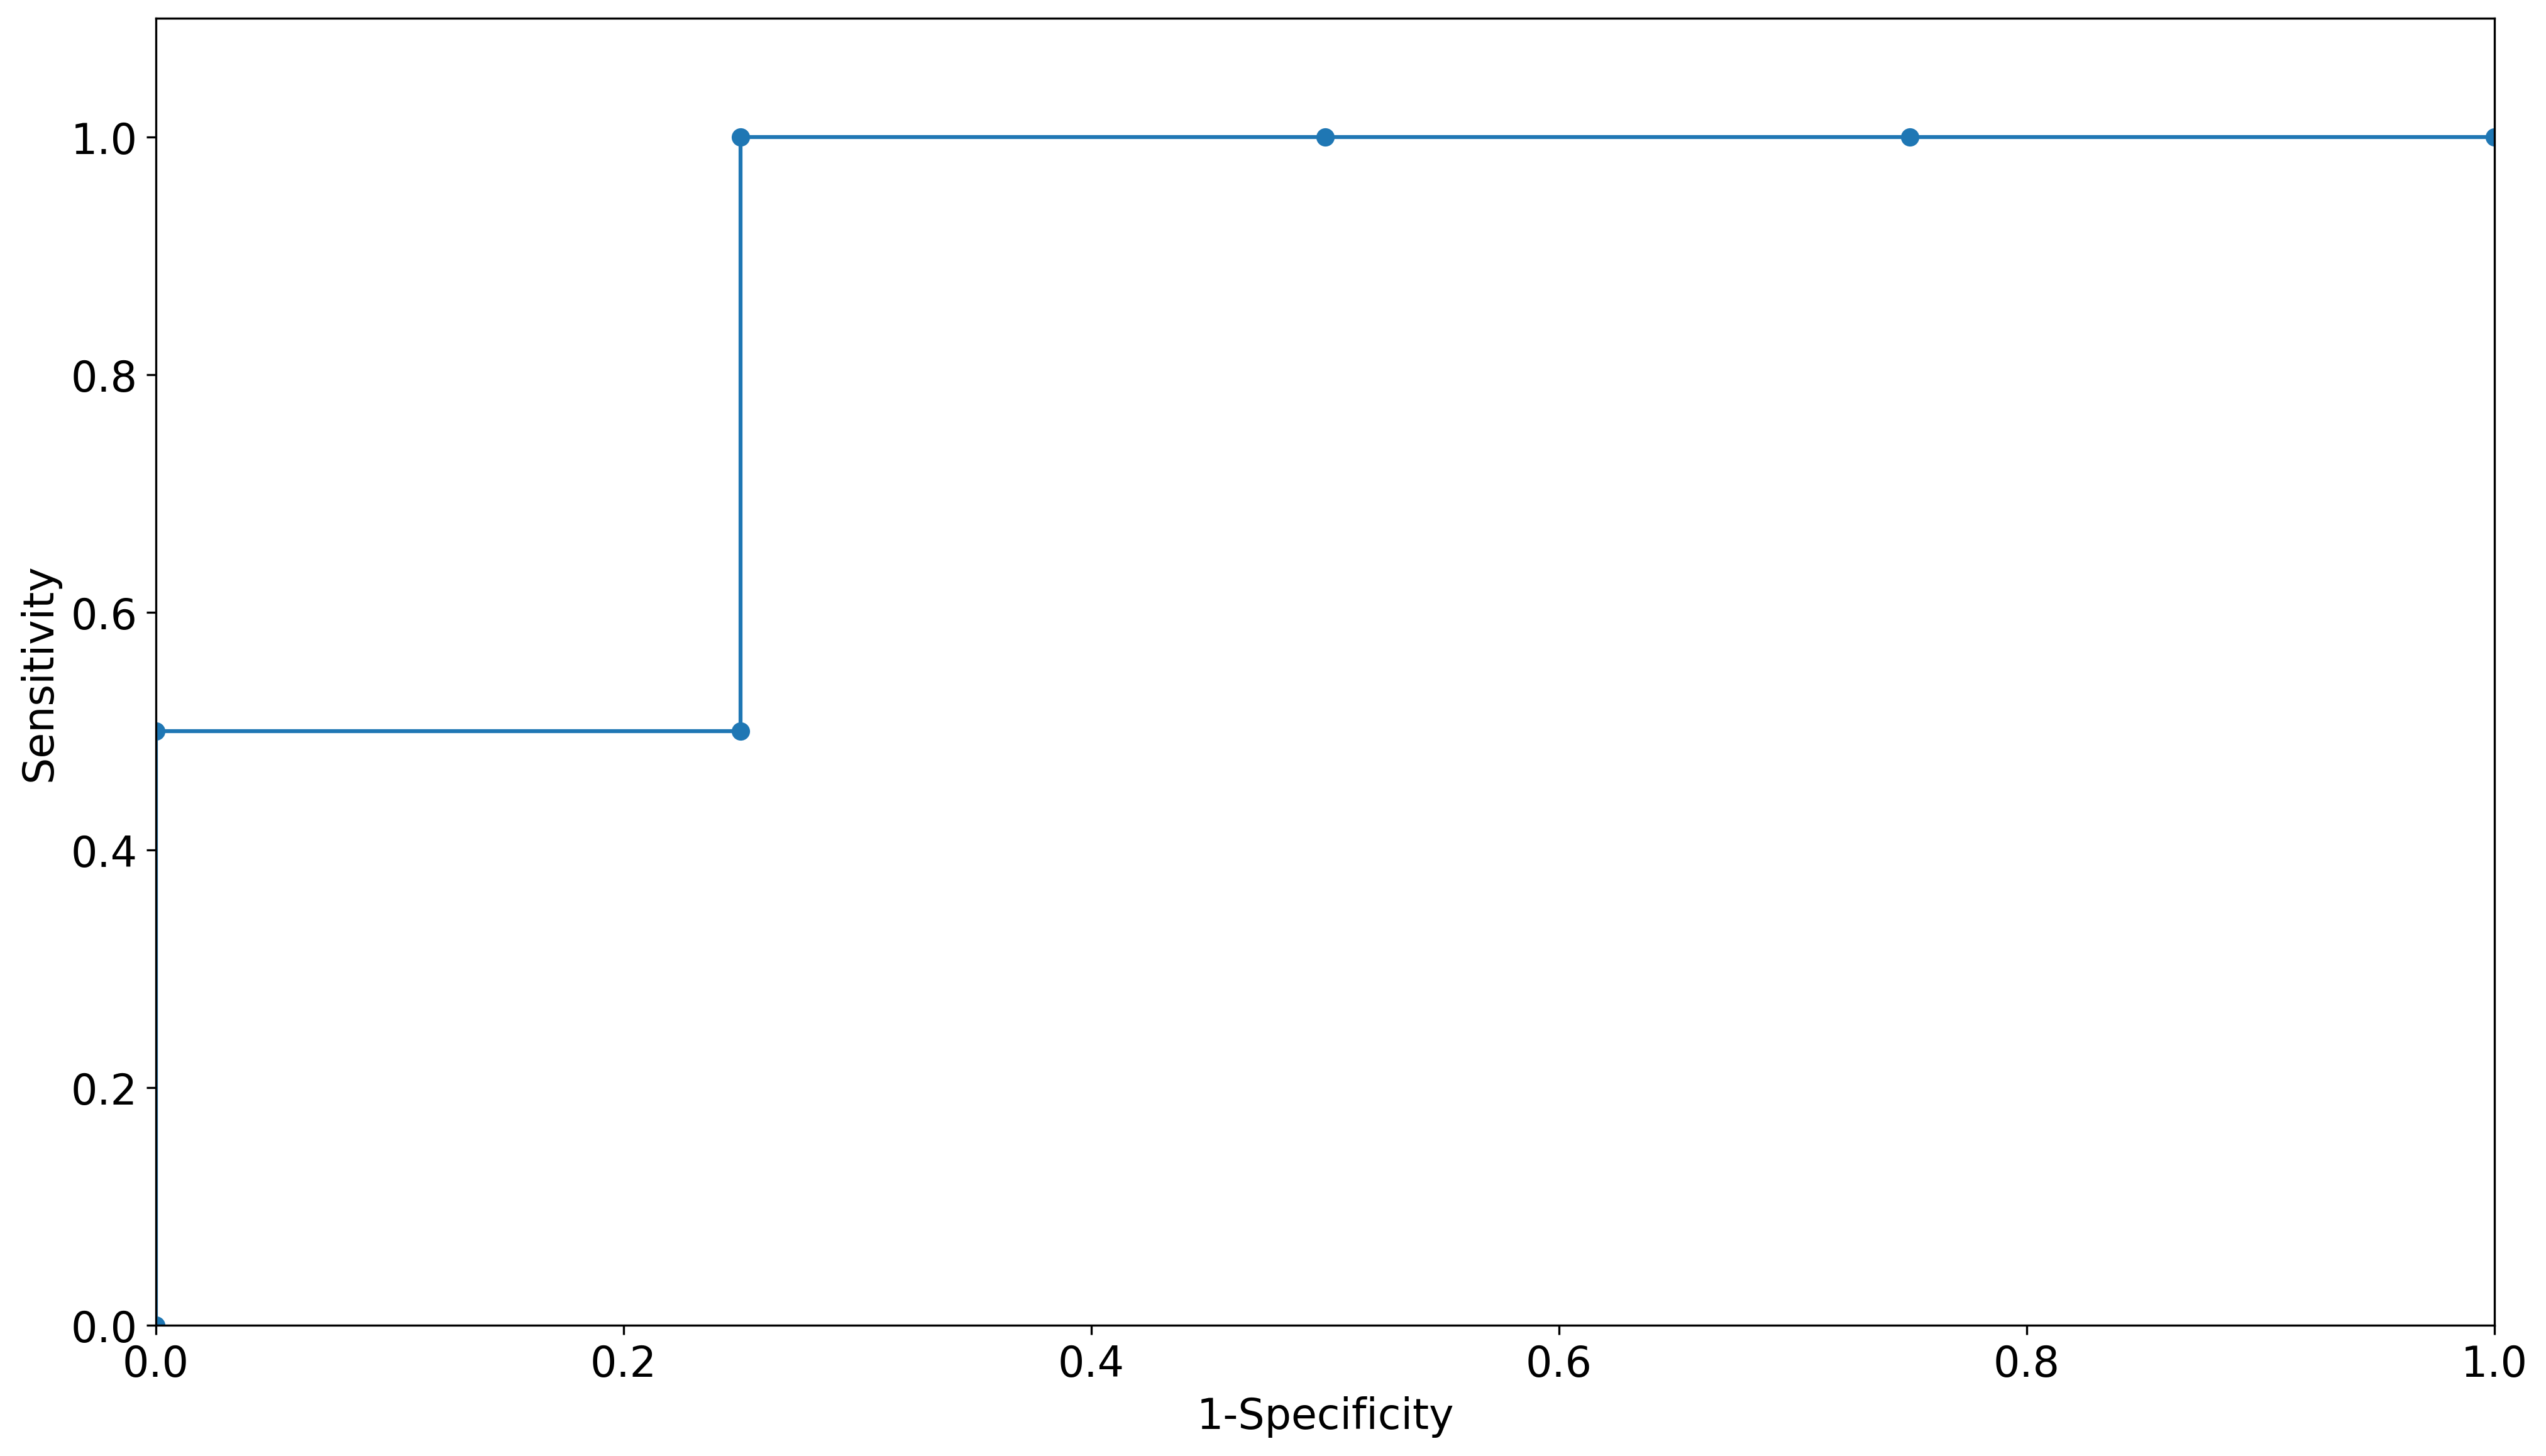

In [20]:
plt.plot(data_roc[:,1],data_roc[:,0], marker='o') 
plt.xlabel('1-Specificity')  
plt.ylabel('Sensitivity')  
plt.xlim([0, 1]) 
plt.ylim([0, 1.1])

Area Under ROC: 0.875


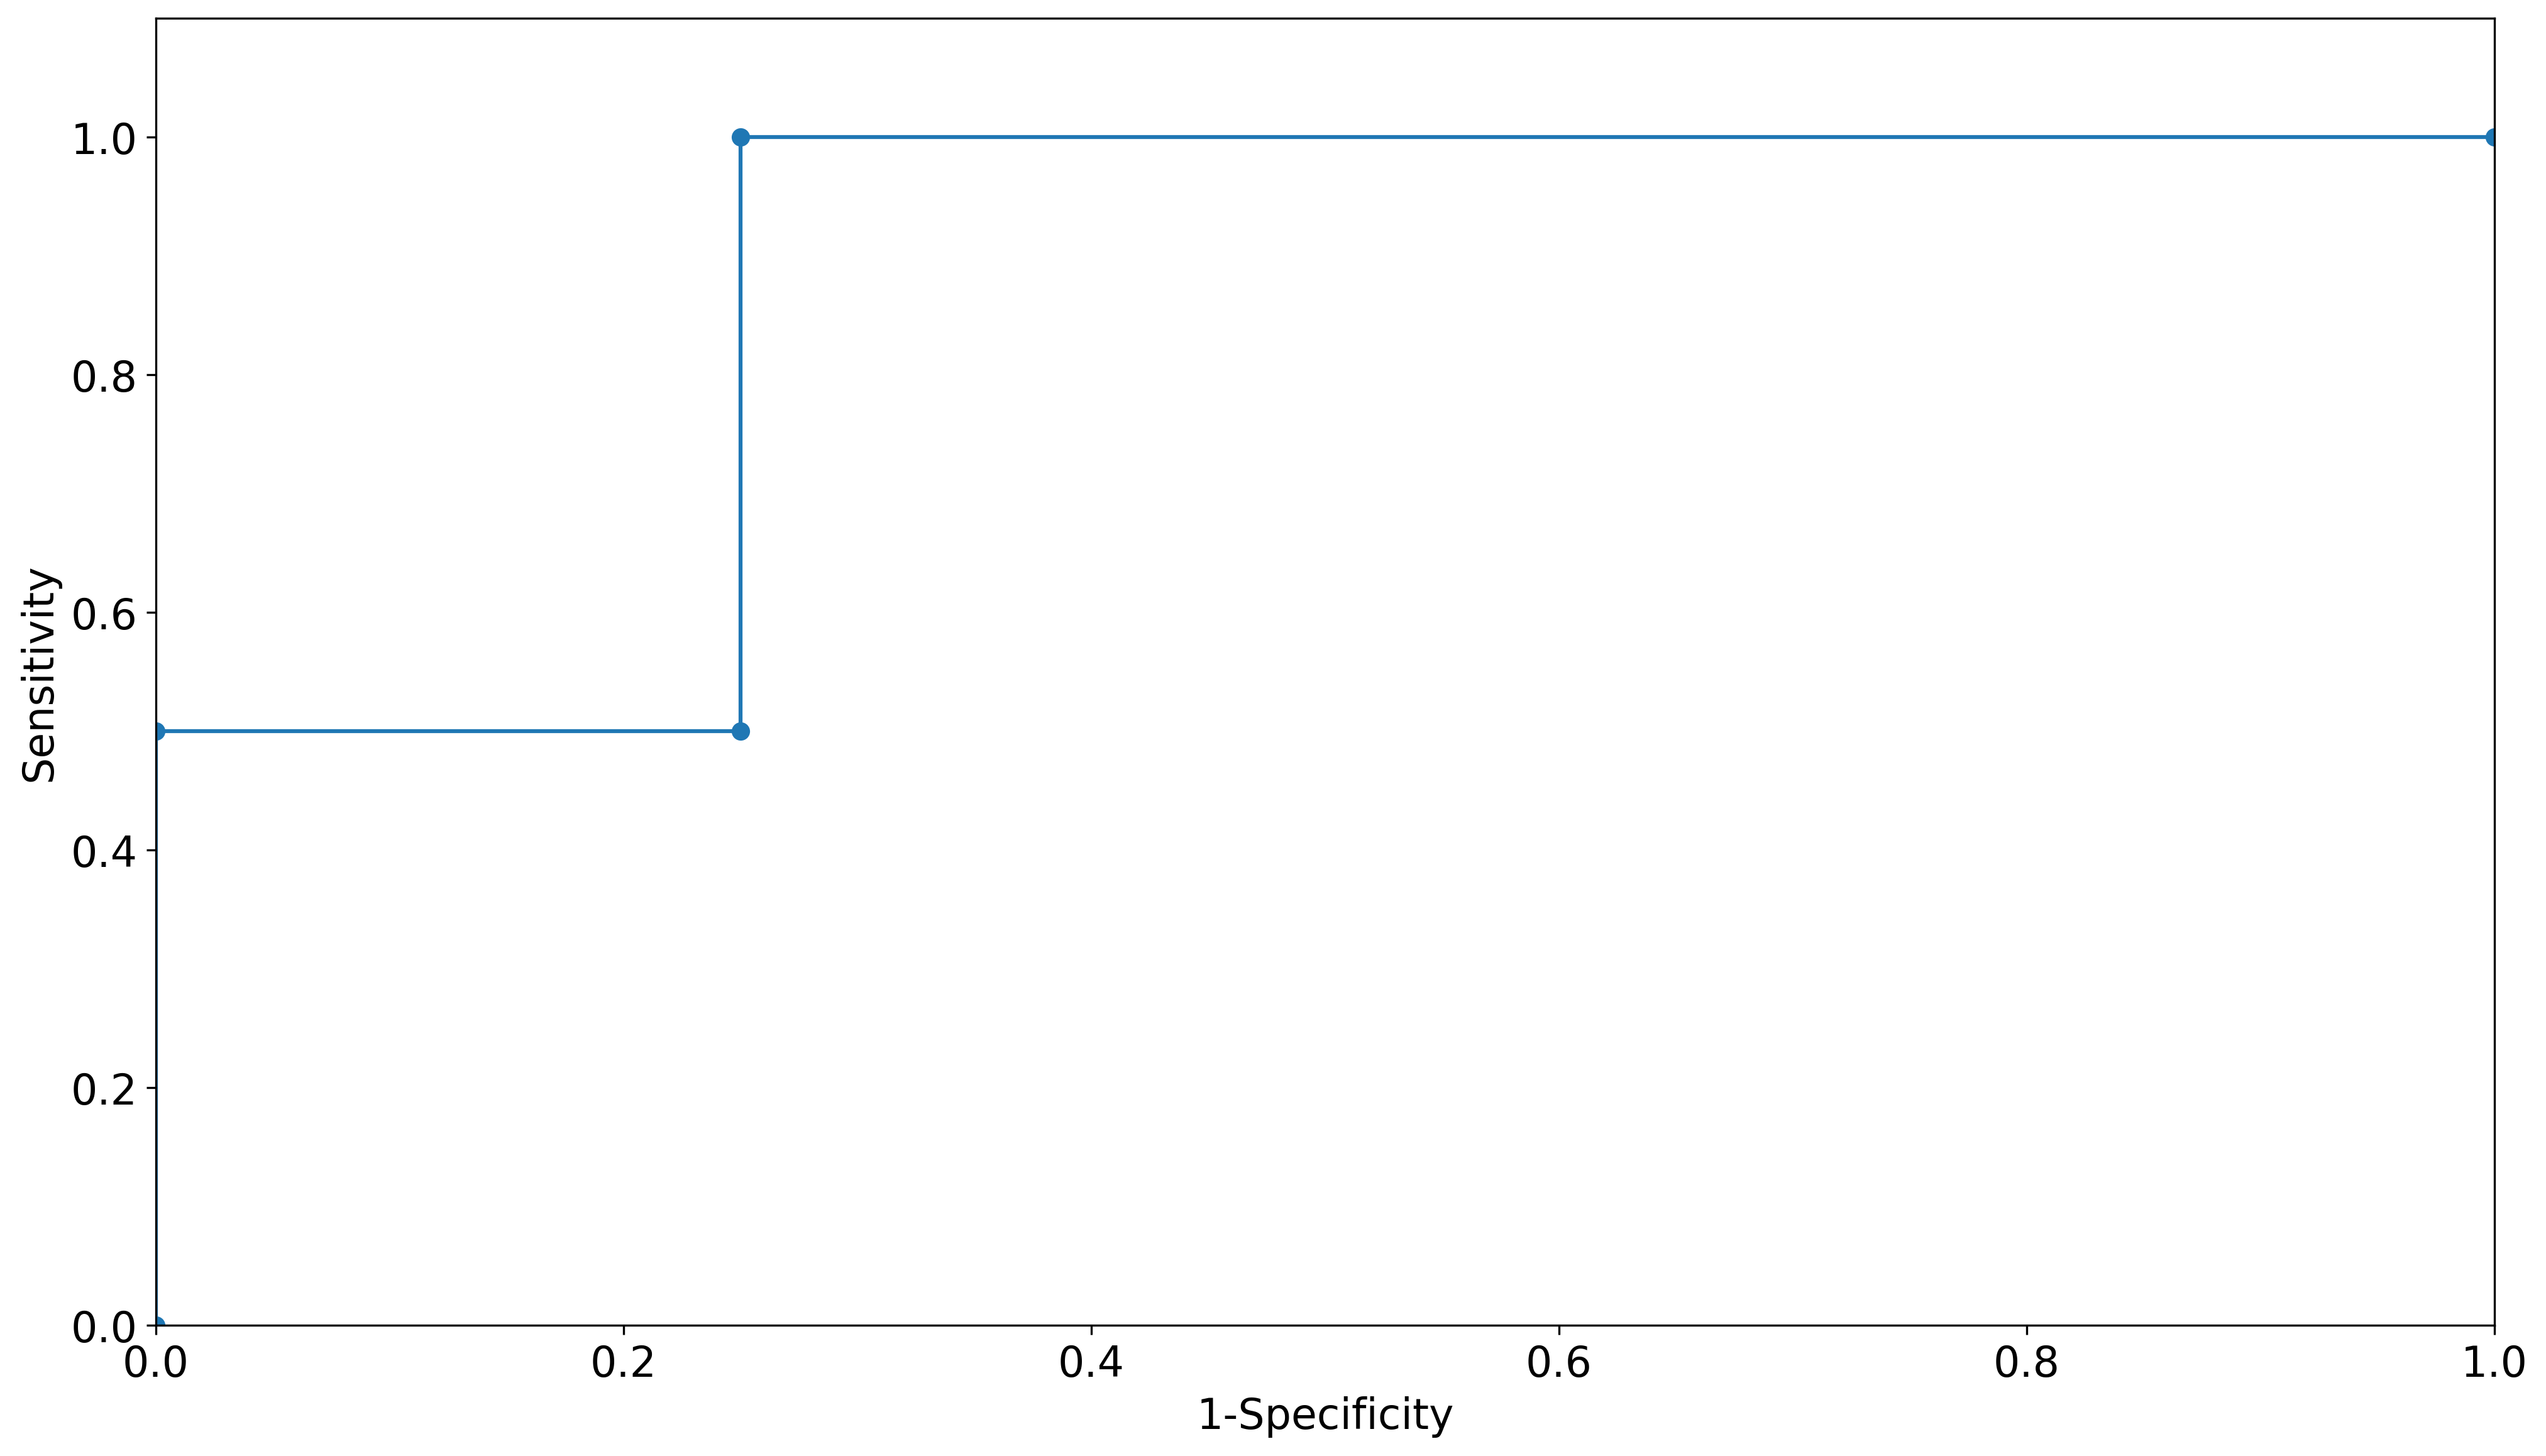

In [21]:
fpr, tpr, thresholds = roc_curve(y_true, PD_pred) 
roc_auc = roc_auc_score(y_true, PD_pred) 
print('Area Under ROC:', roc_auc)  
plt.figure()  
plt.plot(fpr, tpr, marker='o') 
plt.xlim([0, 1])  
plt.ylim([0, 1.1])  
plt.ylabel('Sensitivity')  
plt.xlabel('1-Specificity') 
plt.show() 

In [22]:
True_PD1 =np.append(np.ones(50000) * 0.04, np.ones(50000) * 0.06, axis=0)  
True_PD2 =np.append(np.ones(50000) * 0.01, np.ones(50000) * 0.09, axis=0)  
x1 = pd.get_dummies(True_PD1)  
x2 = pd.get_dummies(True_PD2)

In [23]:
np.random.seed(seed=123)  
defaults1 = np.random.uniform(size=len(True_PD1)) < True_PD1  
defaults2 = np.random.uniform(size=len(True_PD2)) < True_PD2 

In [24]:
print('Default rate 1:',np.mean(defaults1, axis=0).round(decimals=4))  
print('Default rate 2:',np.mean(defaults2, axis=0).round(decimals=4))

Default rate 1: 0.0504
Default rate 2: 0.0497


In [25]:
lr_1 = sm.Logit(defaults1, x1).fit()  
print(lr_1.summary()) 

Optimization terminated successfully.
         Current function value: 0.198316
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99998
Method:                           MLE   Df Model:                            1
Date:                Mon, 04 Aug 2025   Pseudo R-squ.:                0.006596
Time:                        16:53:30   Log-Likelihood:                -19832.
converged:                       True   LL-Null:                       -19963.
Covariance Type:            nonrobust   LLR p-value:                 3.211e-59
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
0.04          -3.1991      0.023   -138.826      0.000      -3.244      -3.154
0.06          -2.7242      0.

In [26]:
lr_2 = sm.Logit(defaults2, x2).fit()  
print(lr_2.summary()) 

Optimization terminated successfully.
         Current function value: 0.179138
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:               100000
Model:                          Logit   Df Residuals:                    99998
Method:                           MLE   Df Model:                            1
Date:                Mon, 04 Aug 2025   Pseudo R-squ.:                 0.09384
Time:                        16:53:55   Log-Likelihood:                -17914.
converged:                       True   LL-Null:                       -19769.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
0.01          -4.5497      0.044   -103.502      0.000      -4.636      -4.464
0.09          -2.3262      0.

AUROC 1: 0.5584
AUROC 2: 0.7077


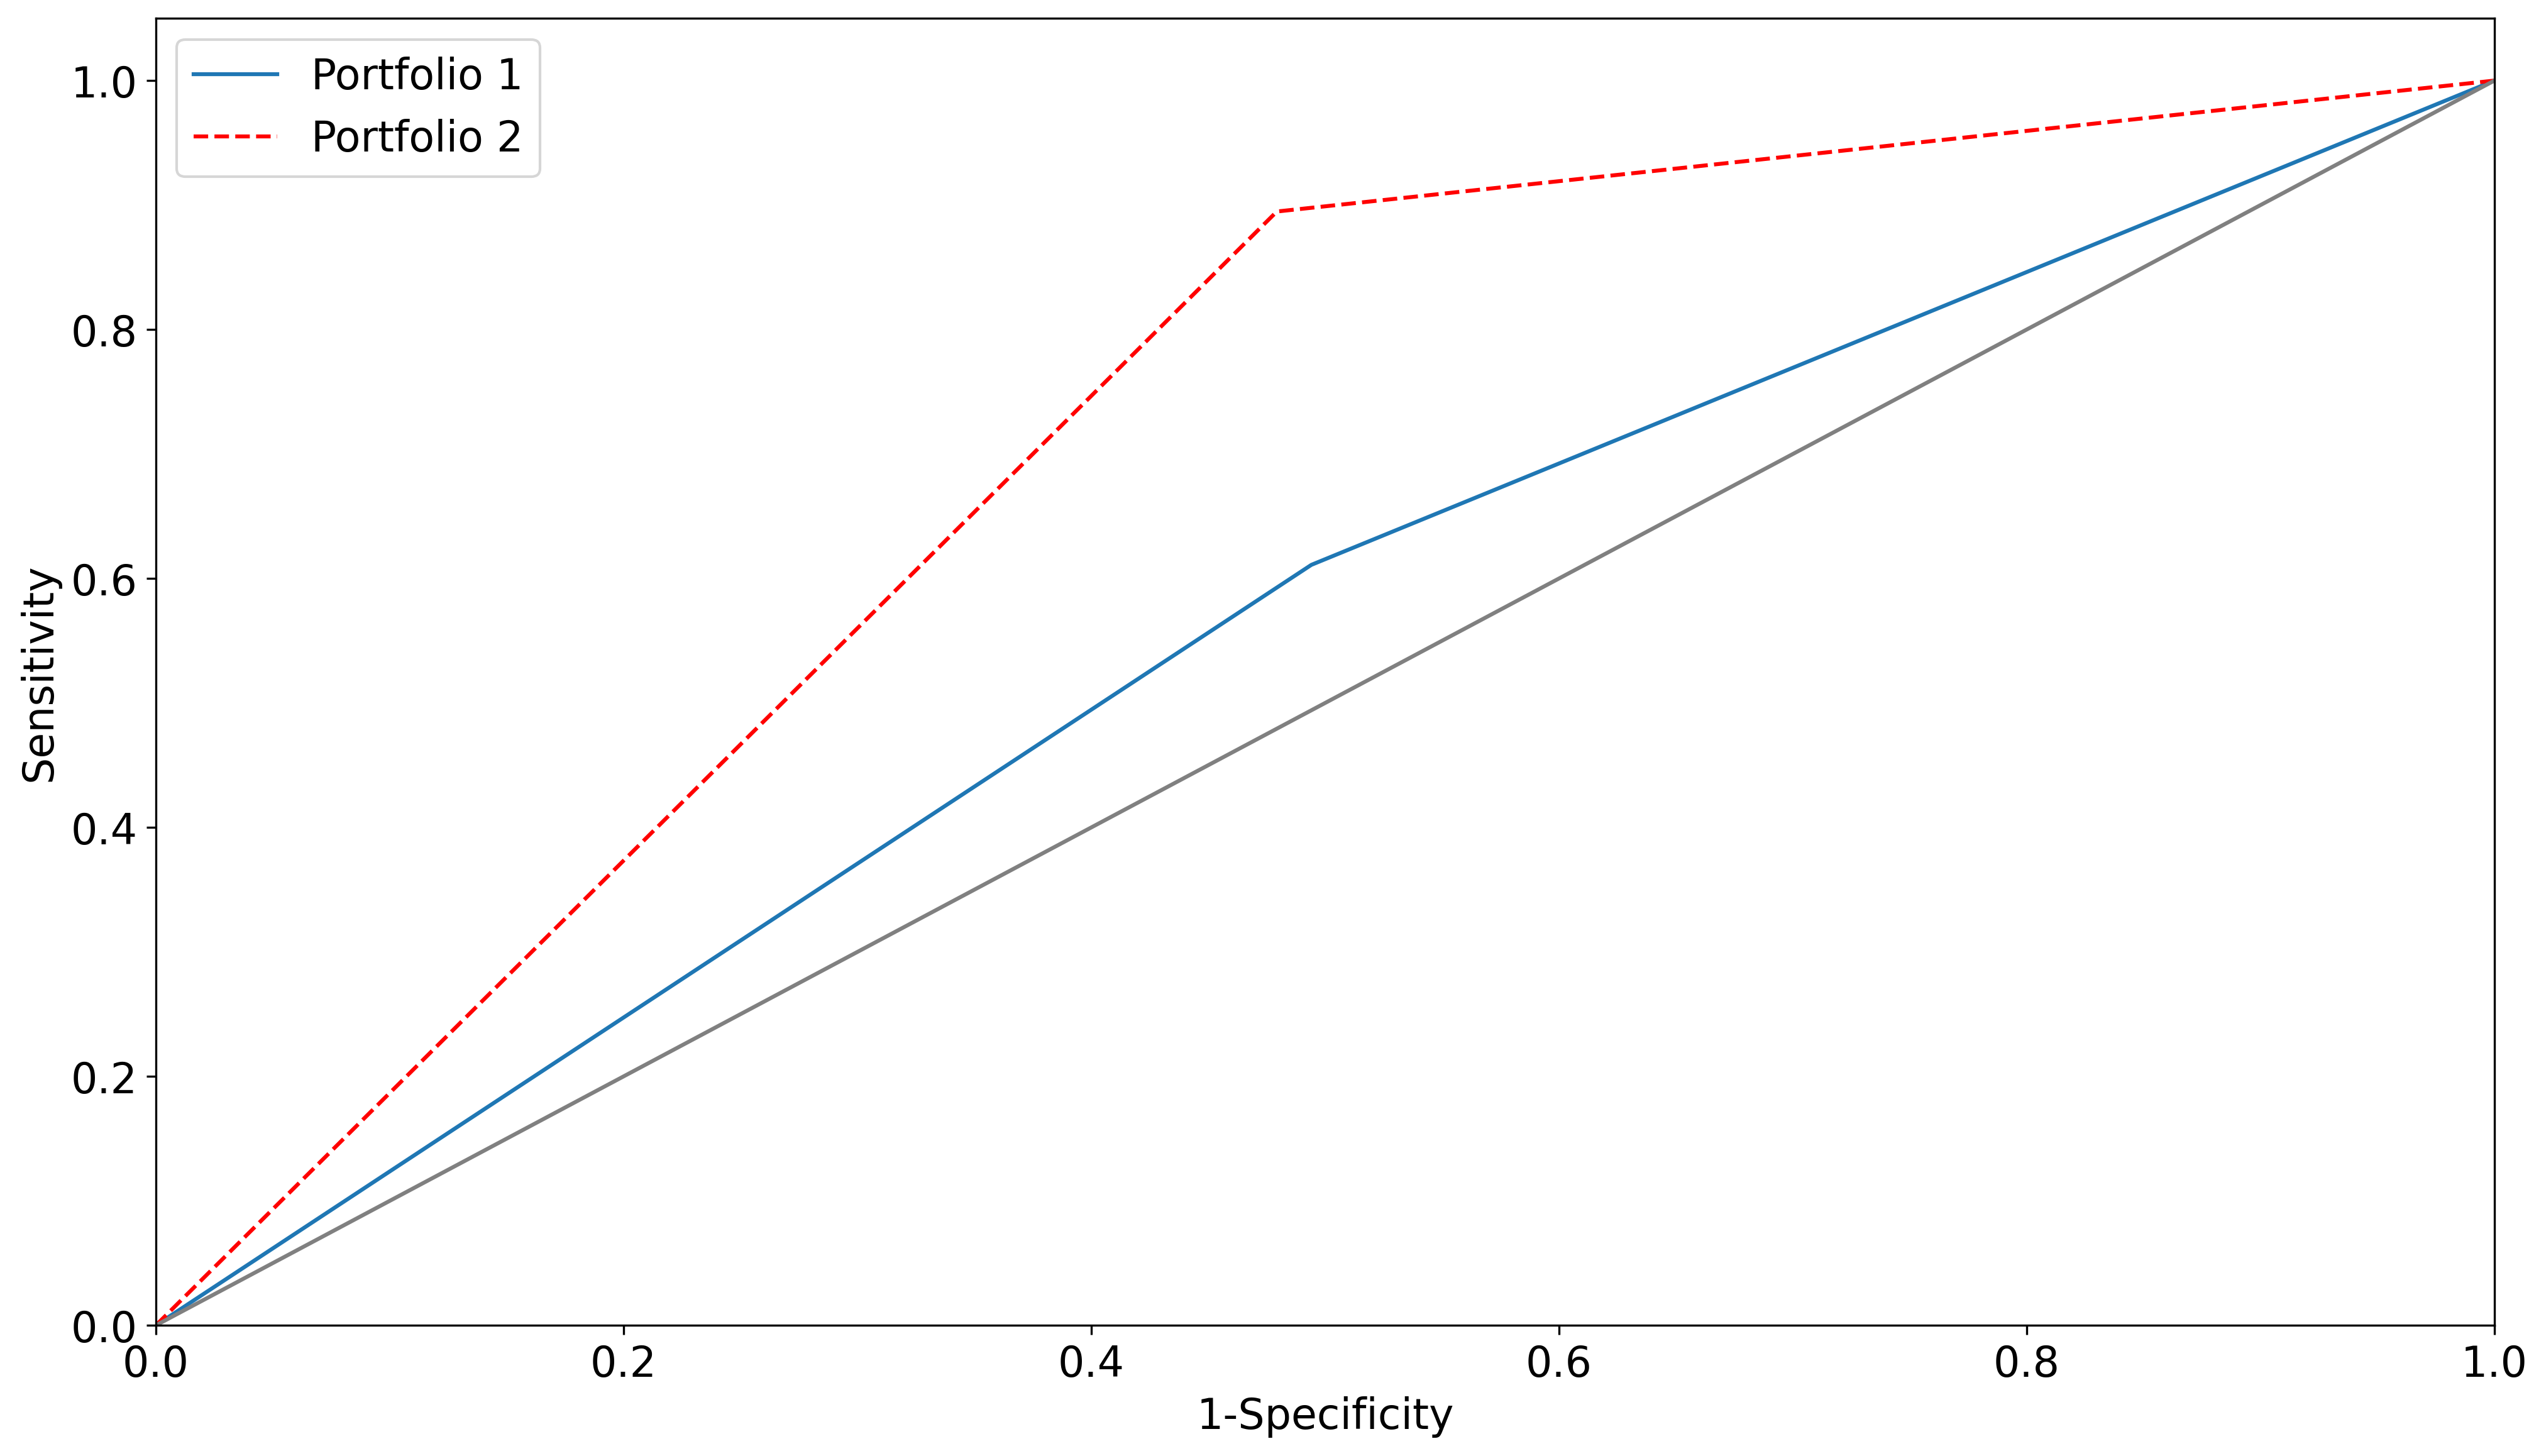

In [27]:
fpr1, tpr1, thresholds1 = roc_curve(defaults1, lr_1.predict(x1))  
roc_auc1 = roc_auc_score(defaults1, lr_1.predict(x1))  
print('AUROC 1:', roc_auc1.round(decimals=4))  
fpr2, tpr2, thresholds2 = roc_curve(defaults2, lr_2.predict(x2)) 
roc_auc2 = roc_auc_score(defaults2, lr_2.predict(x2))  
print('AUROC 2:', roc_auc2.round(decimals=4))  
plt.figure()  
plt.plot(fpr1, tpr1, label='Portfolio 1')  
plt.plot(fpr2, tpr2, color='red', label='Portfolio 2', linestyle='--') 
plt.plot([0, 1], [0, 1], color='grey')  
plt.xlim([0.0, 1.0])  
plt.ylim([0.0, 1.05])  
plt.ylabel('Sensitivity') 
plt.xlabel('1-Specificity') 
plt.legend(loc="best")  
plt.show() 

In [28]:
brier_score1 = np.mean((np.asarray(PD_pred) - np.asarray(y_true))**2)  
print('Brier score:', brier_score1.round(decimals=4))

Brier score: 0.2984


In [29]:
brier_score2 = brier_score_loss(y_true, PD_pred)  
print('Brier score:', brier_score2.round(decimals=4))

Brier score: 0.2984


In [31]:
corr,_= stats.pearsonr(y_true, PD_pred)  
r2_OLS = corr**2 
print('R-squared (OLS):', r2_OLS.round(decimals=4)) 

R-squared (OLS): 0.4321


In [32]:
num = np.sum((np.asarray(y_true) - np.asarray(PD_pred))**2) 
denom = np.sum((np.asarray(y_true) - np.mean(np.asarray(y_true)))**2)  
r2 = 1-num/denom  
print('R-squared:', r2.round(decimals=4)) 

R-squared: -0.3428


In [33]:
r2 = r2_score(y_true, PD_pred)  
print('R-square:', r2.round(decimals=4)) 

R-square: -0.3428


In [34]:
n = len(PD_pred) 
pi_0 = np.mean(PD_pred) 
print('Counts:', n)  
print('Mean PD:', pi_0.round(decimals=4)) 

Counts: 6
Mean PD: 0.0367


In [35]:
print('Defaults:', 'CDF:')  
for d in range(0,n):  
    print(d, binom.cdf(d, n, pi_0).round(decimals=4)) 

Defaults: CDF:
0 0.7992
1 0.9817
2 0.9991
3 1.0
4 1.0
5 1.0


In [36]:
alpha=0.01 
k_star = norm.ppf(1-alpha) * np.sqrt(n * pi_0 * (1-pi_0)) + n * pi_0  
p_star = norm.ppf(1-alpha) * np.sqrt(pi_0 * (1-pi_0)/n) + pi_0  
print('k_star:', k_star.round(decimals=4))  
print('p_star:', p_star.round(decimals=4))

k_star: 1.291
p_star: 0.2152


In [37]:
d = 2  
print('Binomial p-value:',binom_test(d, n=n, p= pi_0, alternative='greater').round(decimals=4)) 

Binomial p-value: 0.0183


Jeffrey's Prior Bayesian 'p-value': 0.0044


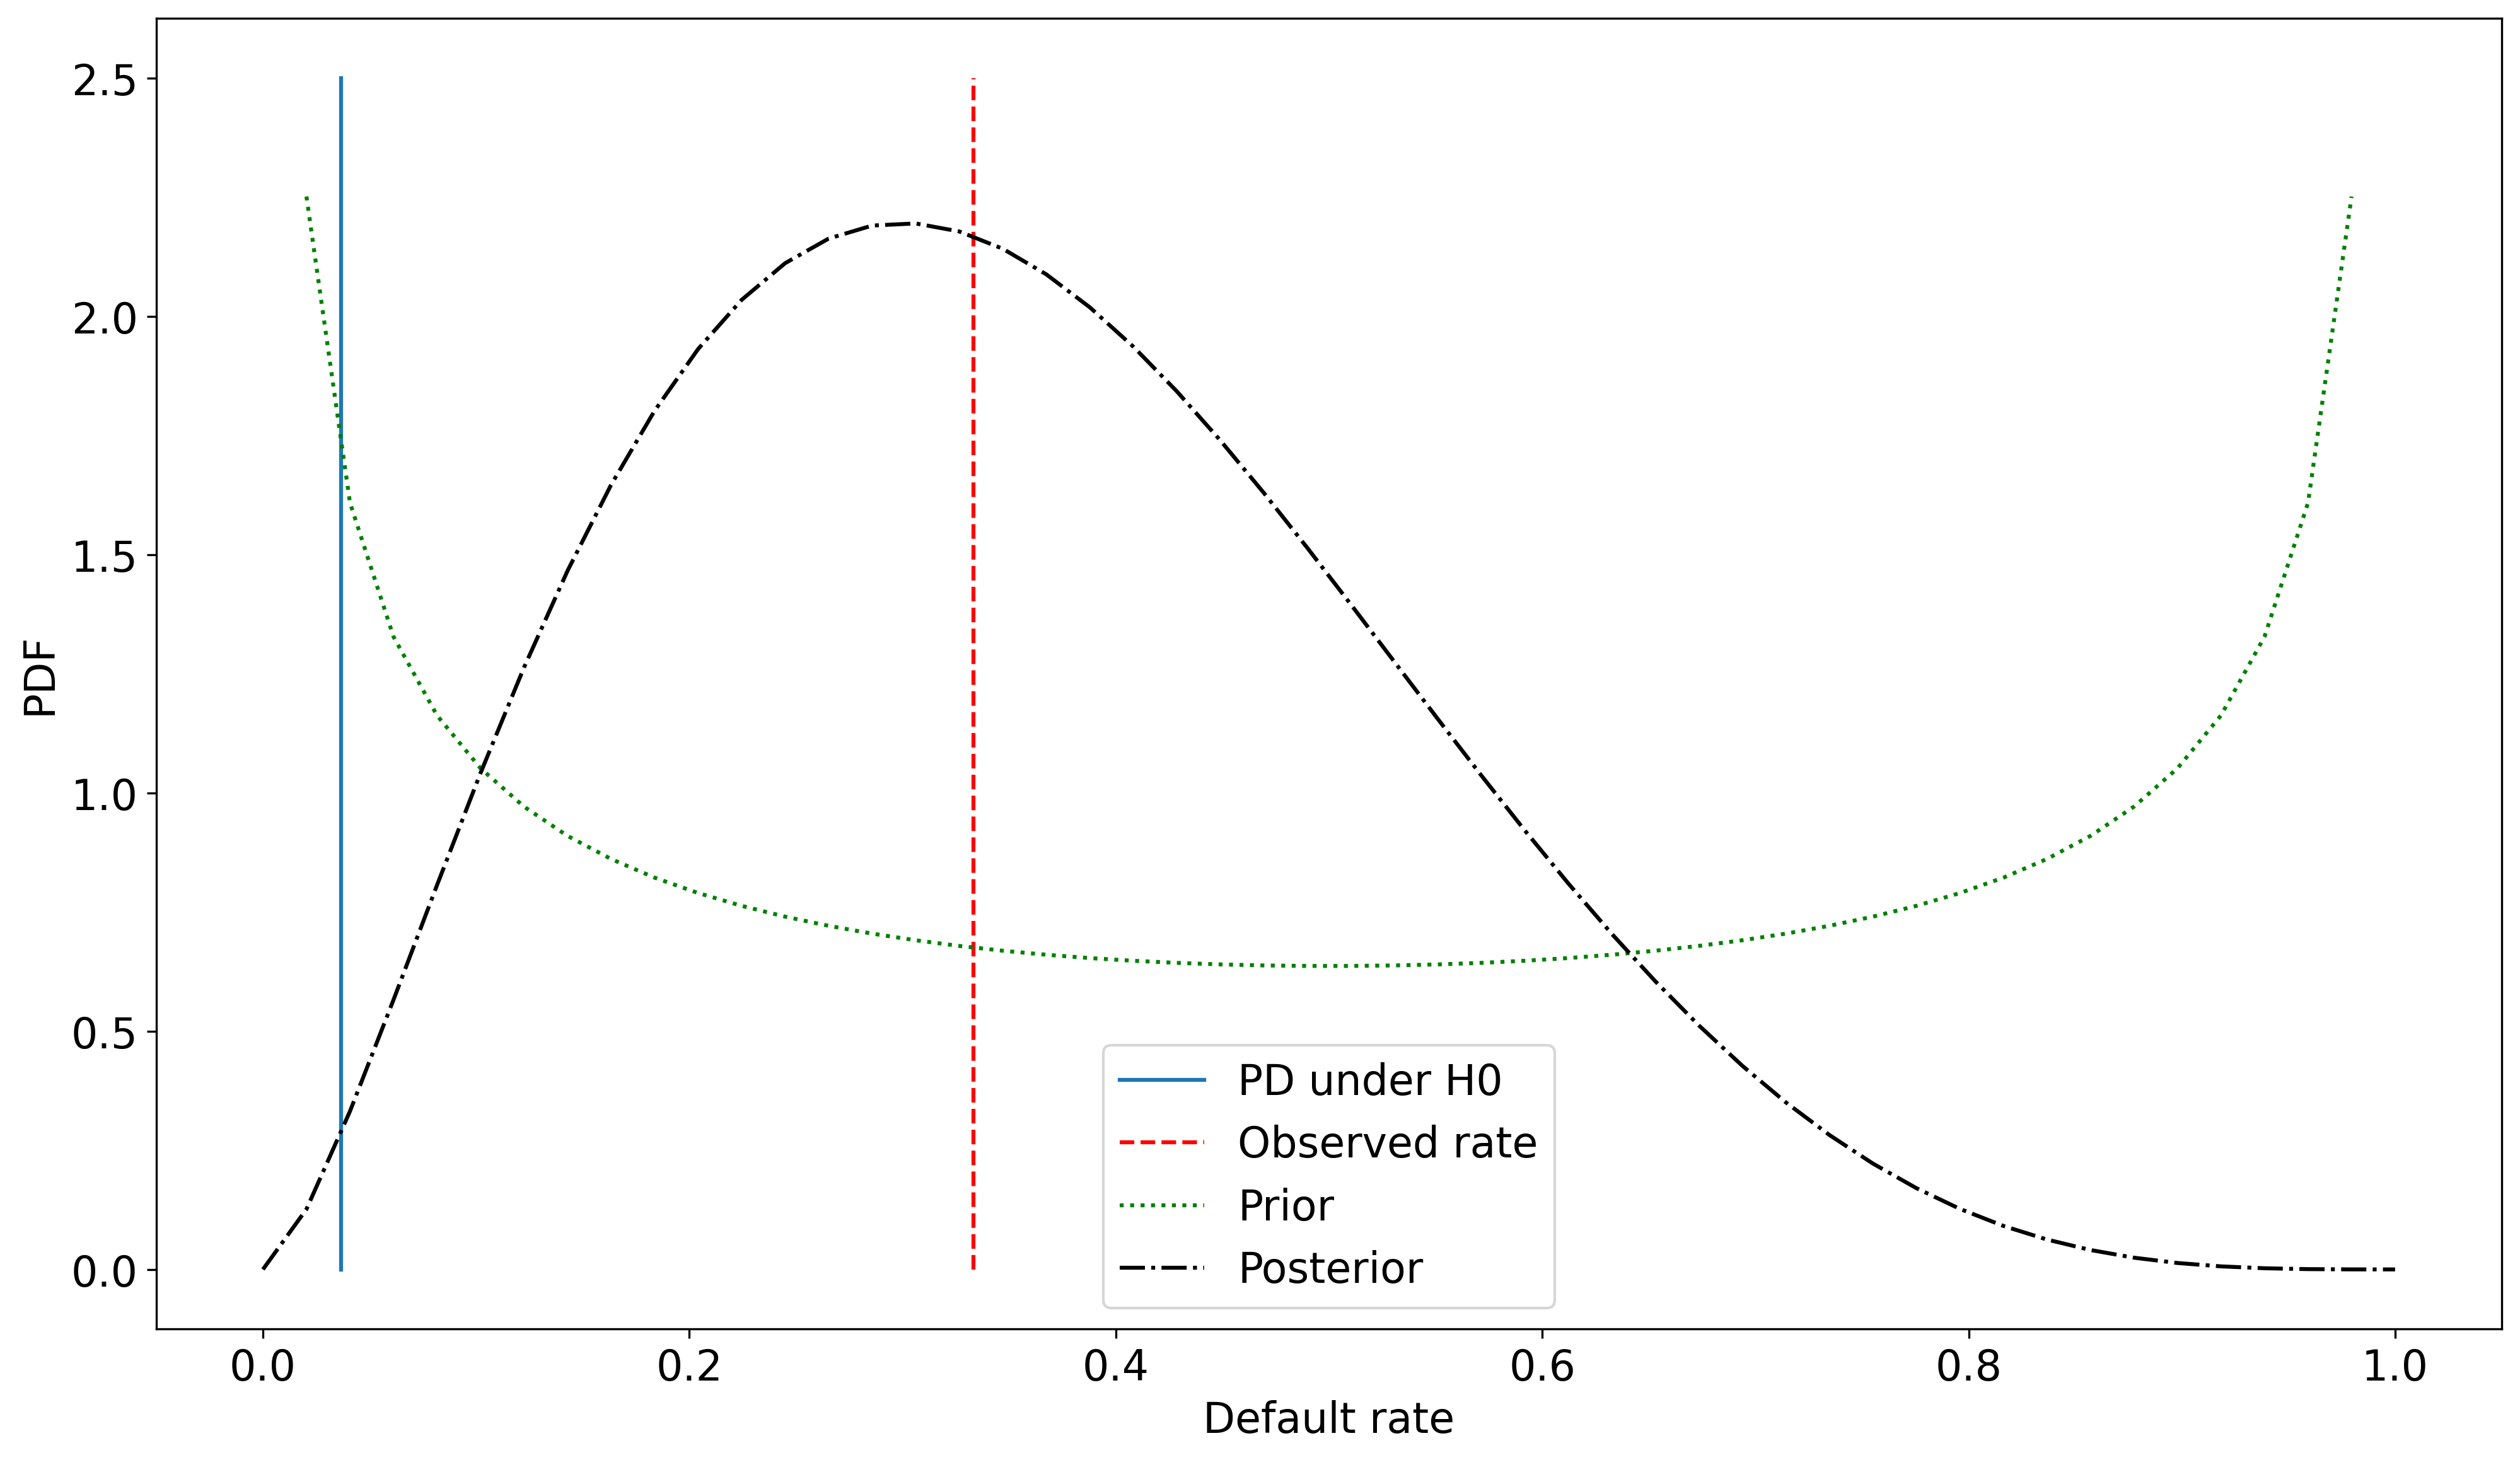

In [38]:
n = len(PD_pred)  
pi_0 = np.mean(PD_pred) 
d= 2
defaultrate = d/n 
x = np.linspace(0, 1, 50)  
prior = beta.pdf(x, 0.5, 0.5)  
posterior = beta.pdf(x, d+0.5, n-d+0.5) 
print("Jeffrey's Prior Bayesian 'p-value':", beta.cdf(pi_0, d+0.5, n-d+0.5).round(decimals  =4))  
plt.plot([pi_0, pi_0], [0, 2.5], label='PD under H0') 
plt.plot([d/n, d/n], [0, 2.5], color='red', linestyle='dashed', label='Observed rate')  
plt.plot(x, prior, color='green', linestyle='dotted', label='Prior') 
plt.plot(x, posterior, color = 'black', linestyle='dashdot', label='Posterior')  
plt.ylabel('PDF')  
plt.xlabel('Default rate')
plt.legend(loc="best") 
plt.show() 


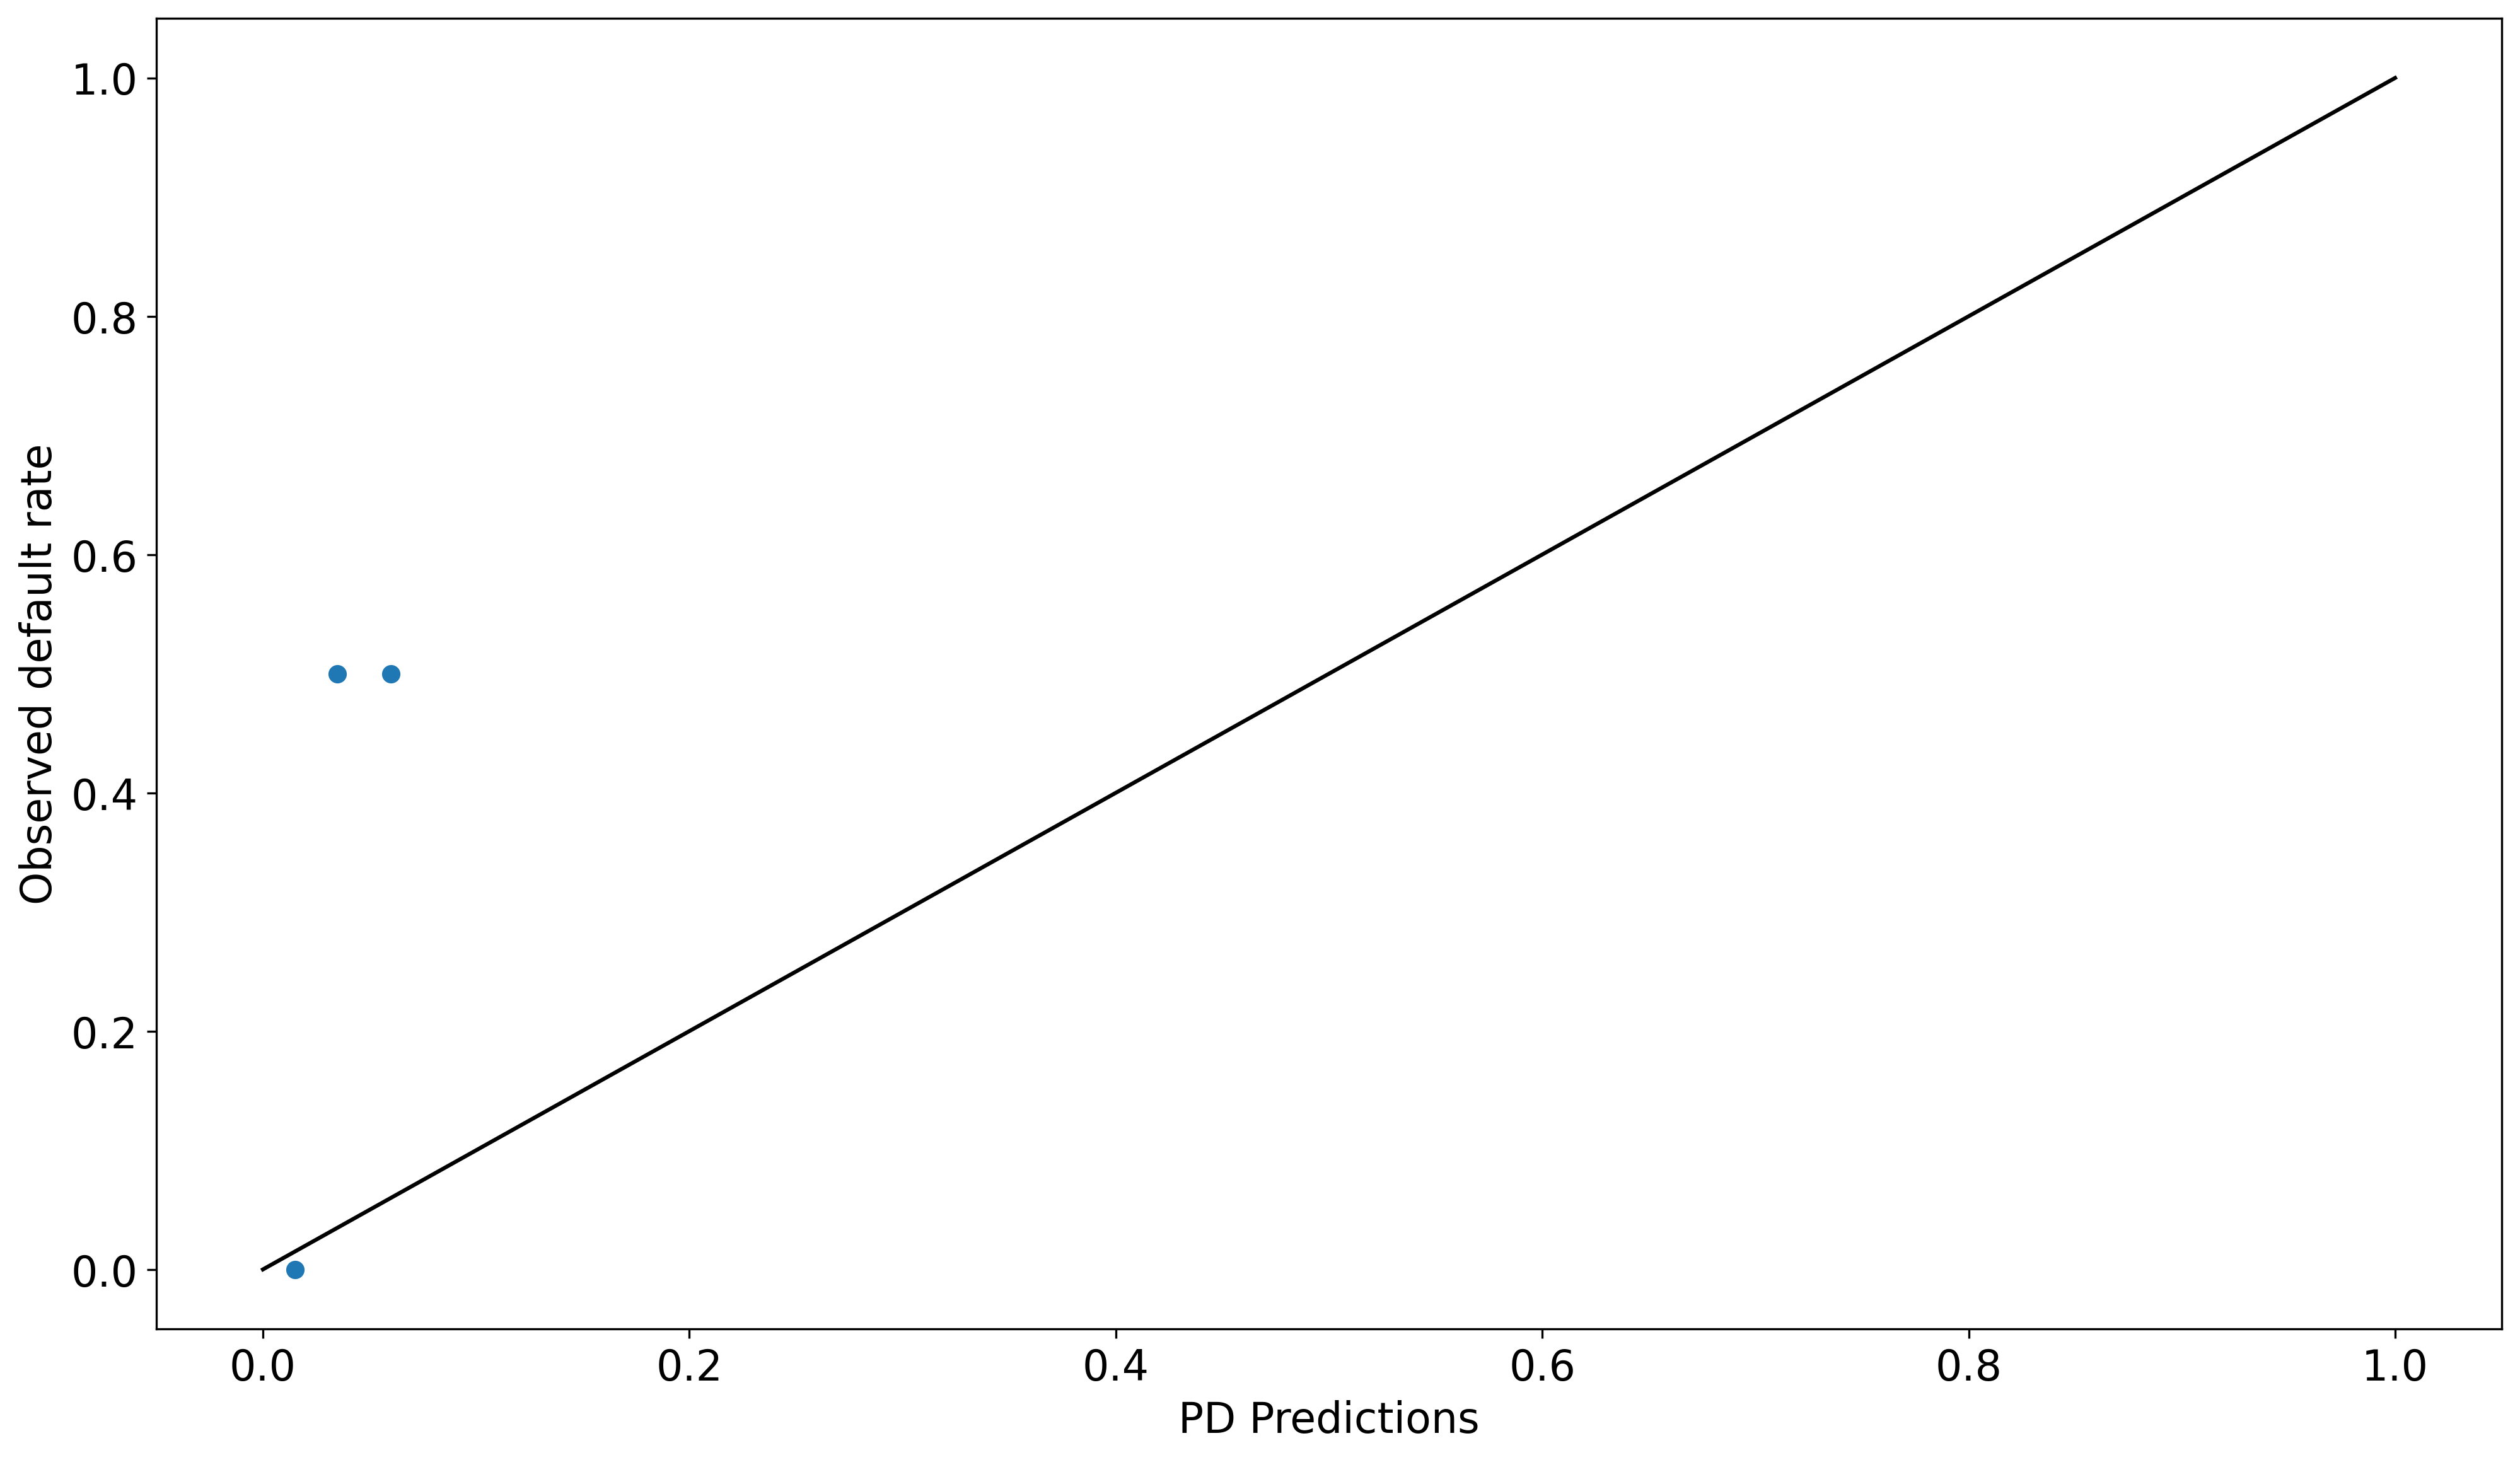

In [39]:
y_true = [1, 0, 1, 0, 0, 0]  
PD_pred =[0.07, 0.05, 0.04, 0.03, 0.02, 0.01] 

#Sorted PD predictions 
n_bins=3  
fop, mpv = calibration_curve(y_true, PD_pred, n_bins=n_bins, strategy = 'quantile') 
plt.plot([0, 1], [0, 1], color = 'black') 
plt.plot(mpv, fop, marker='o', linestyle='') 
plt.ylabel('Observed default rate')  
plt.xlabel('PD Predictions')  
plt.show() 


In [40]:
mpv

array([0.015, 0.035, 0.06 ])

In [41]:
n_g = len(y_true)/n_bins 
O_g = fop * n_g  
np_g = n_g * mpv 
num = (O_g-np_g)**2  
denom = np_g * (1-mpv) 
ratio = num/denom
 

In [42]:
HL = np.sum(ratio).round(4)  
pvalue = 1-chi2.cdf(HL,n_bins-1).round(4) 
print('HL statistic:', HL) 
print('p-value:', pvalue.round(decimals=4))

HL statistic: 19.6996
p-value: 0.0001


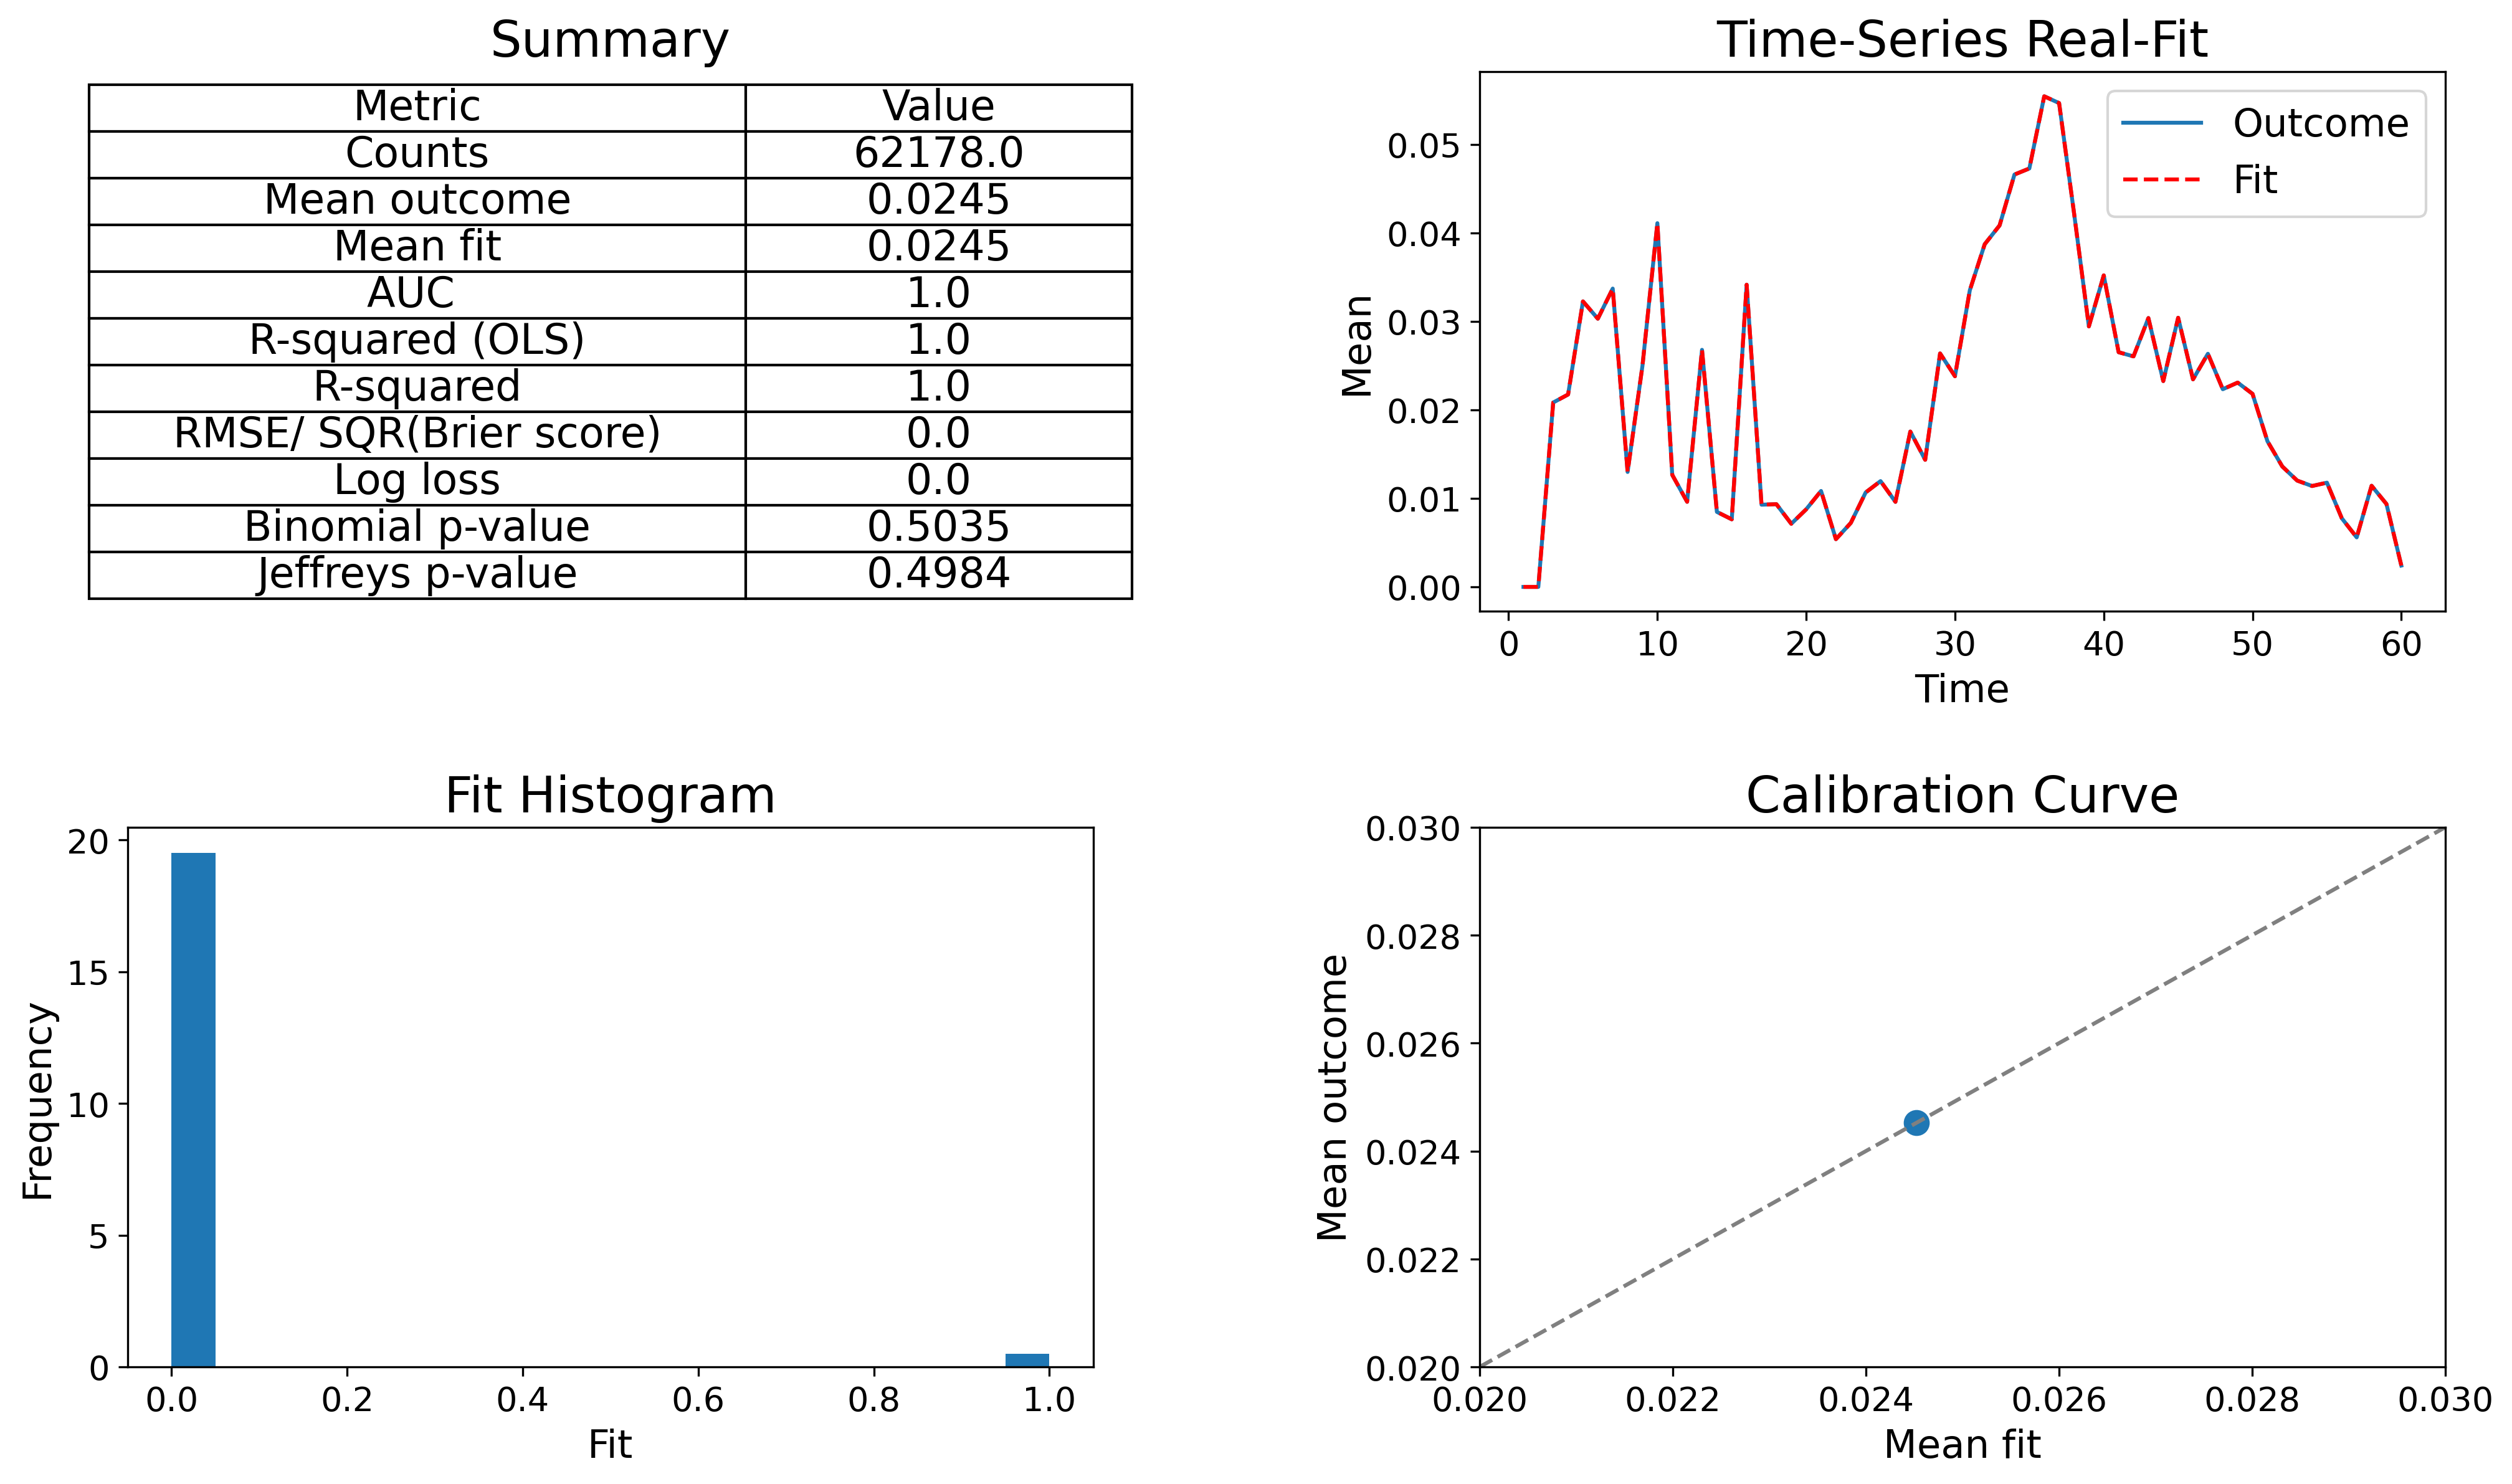

In [43]:
default_time = data.default_time.values 
time = data.time.values  
validation(default_time, default_time, time) 

In [44]:
data = data.query('time <=40').copy() 
_, data_train, data_test, X_train_scaled, X_test_scaled, y_train, y_test = dataprep(data,  depvar='default_time', splitvar='time', threshold=26)

In [45]:
print('Shape train data:', X_train_scaled.shape)  
print('Shape test data:', X_test_scaled.shape) 
print('Default rate train data:', np.mean(y_train).round(4))  
print('Default rate test data:', np.mean(y_test).round(4))

Shape train data: (12702, 11)
Shape test data: (27368, 11)
Default rate train data: 0.0104
Default rate test data: 0.0355


In [46]:
model_lr1 = LogisticRegression(penalty='none', fit_intercept=True, solver='saga', tol =1e-15, max_iter=10000)  
model_lr1.fit(X_train_scaled, y_train)  
print('Coefficients:', model_lr1.coef_.round(decimals=4)) 
print('Intercept', model_lr1.intercept_.round(decimals=4))

Coefficients: [[-0.2817 -0.2565  0.2965 -0.8004  0.0186 -0.0263  0.09    0.0147 -0.0978
  -0.056  -0.2978]]
Intercept [-4.9873]


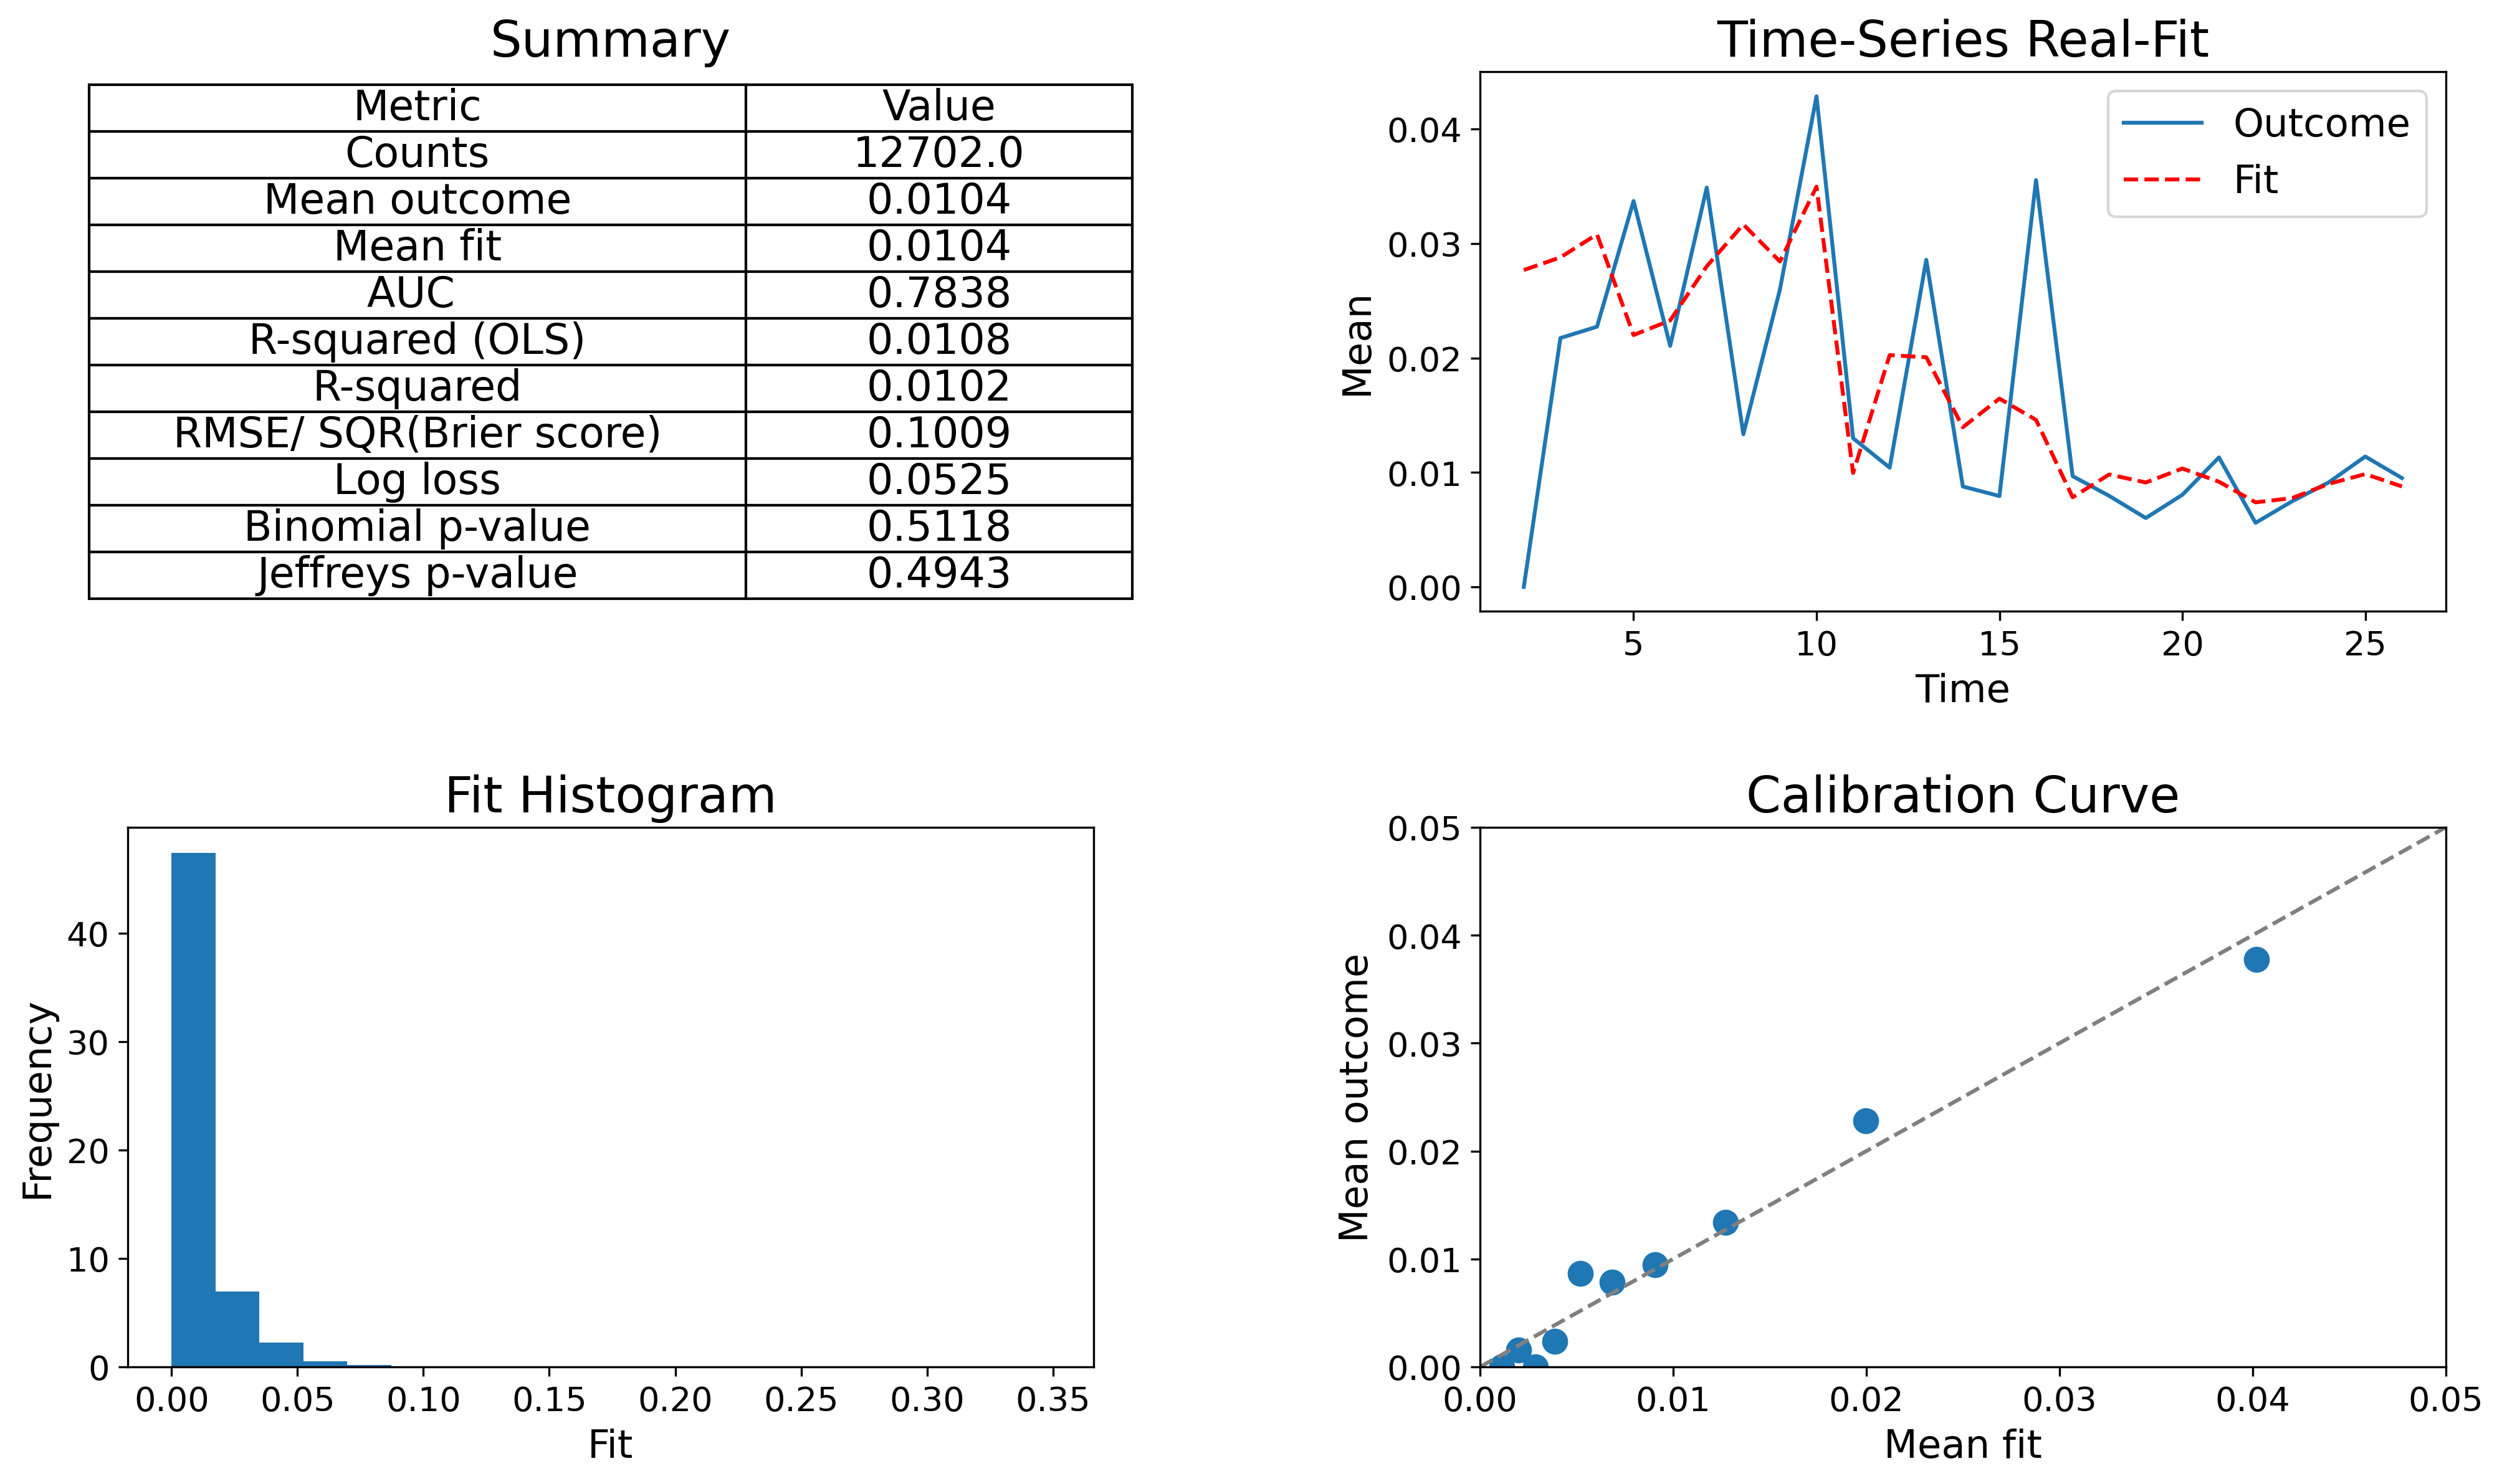

In [47]:
predictions_train = model_lr1.predict_proba(X_train_scaled)[:,1].T  
validation(predictions_train, y_train, data_train.loc[:,'time'].values)  

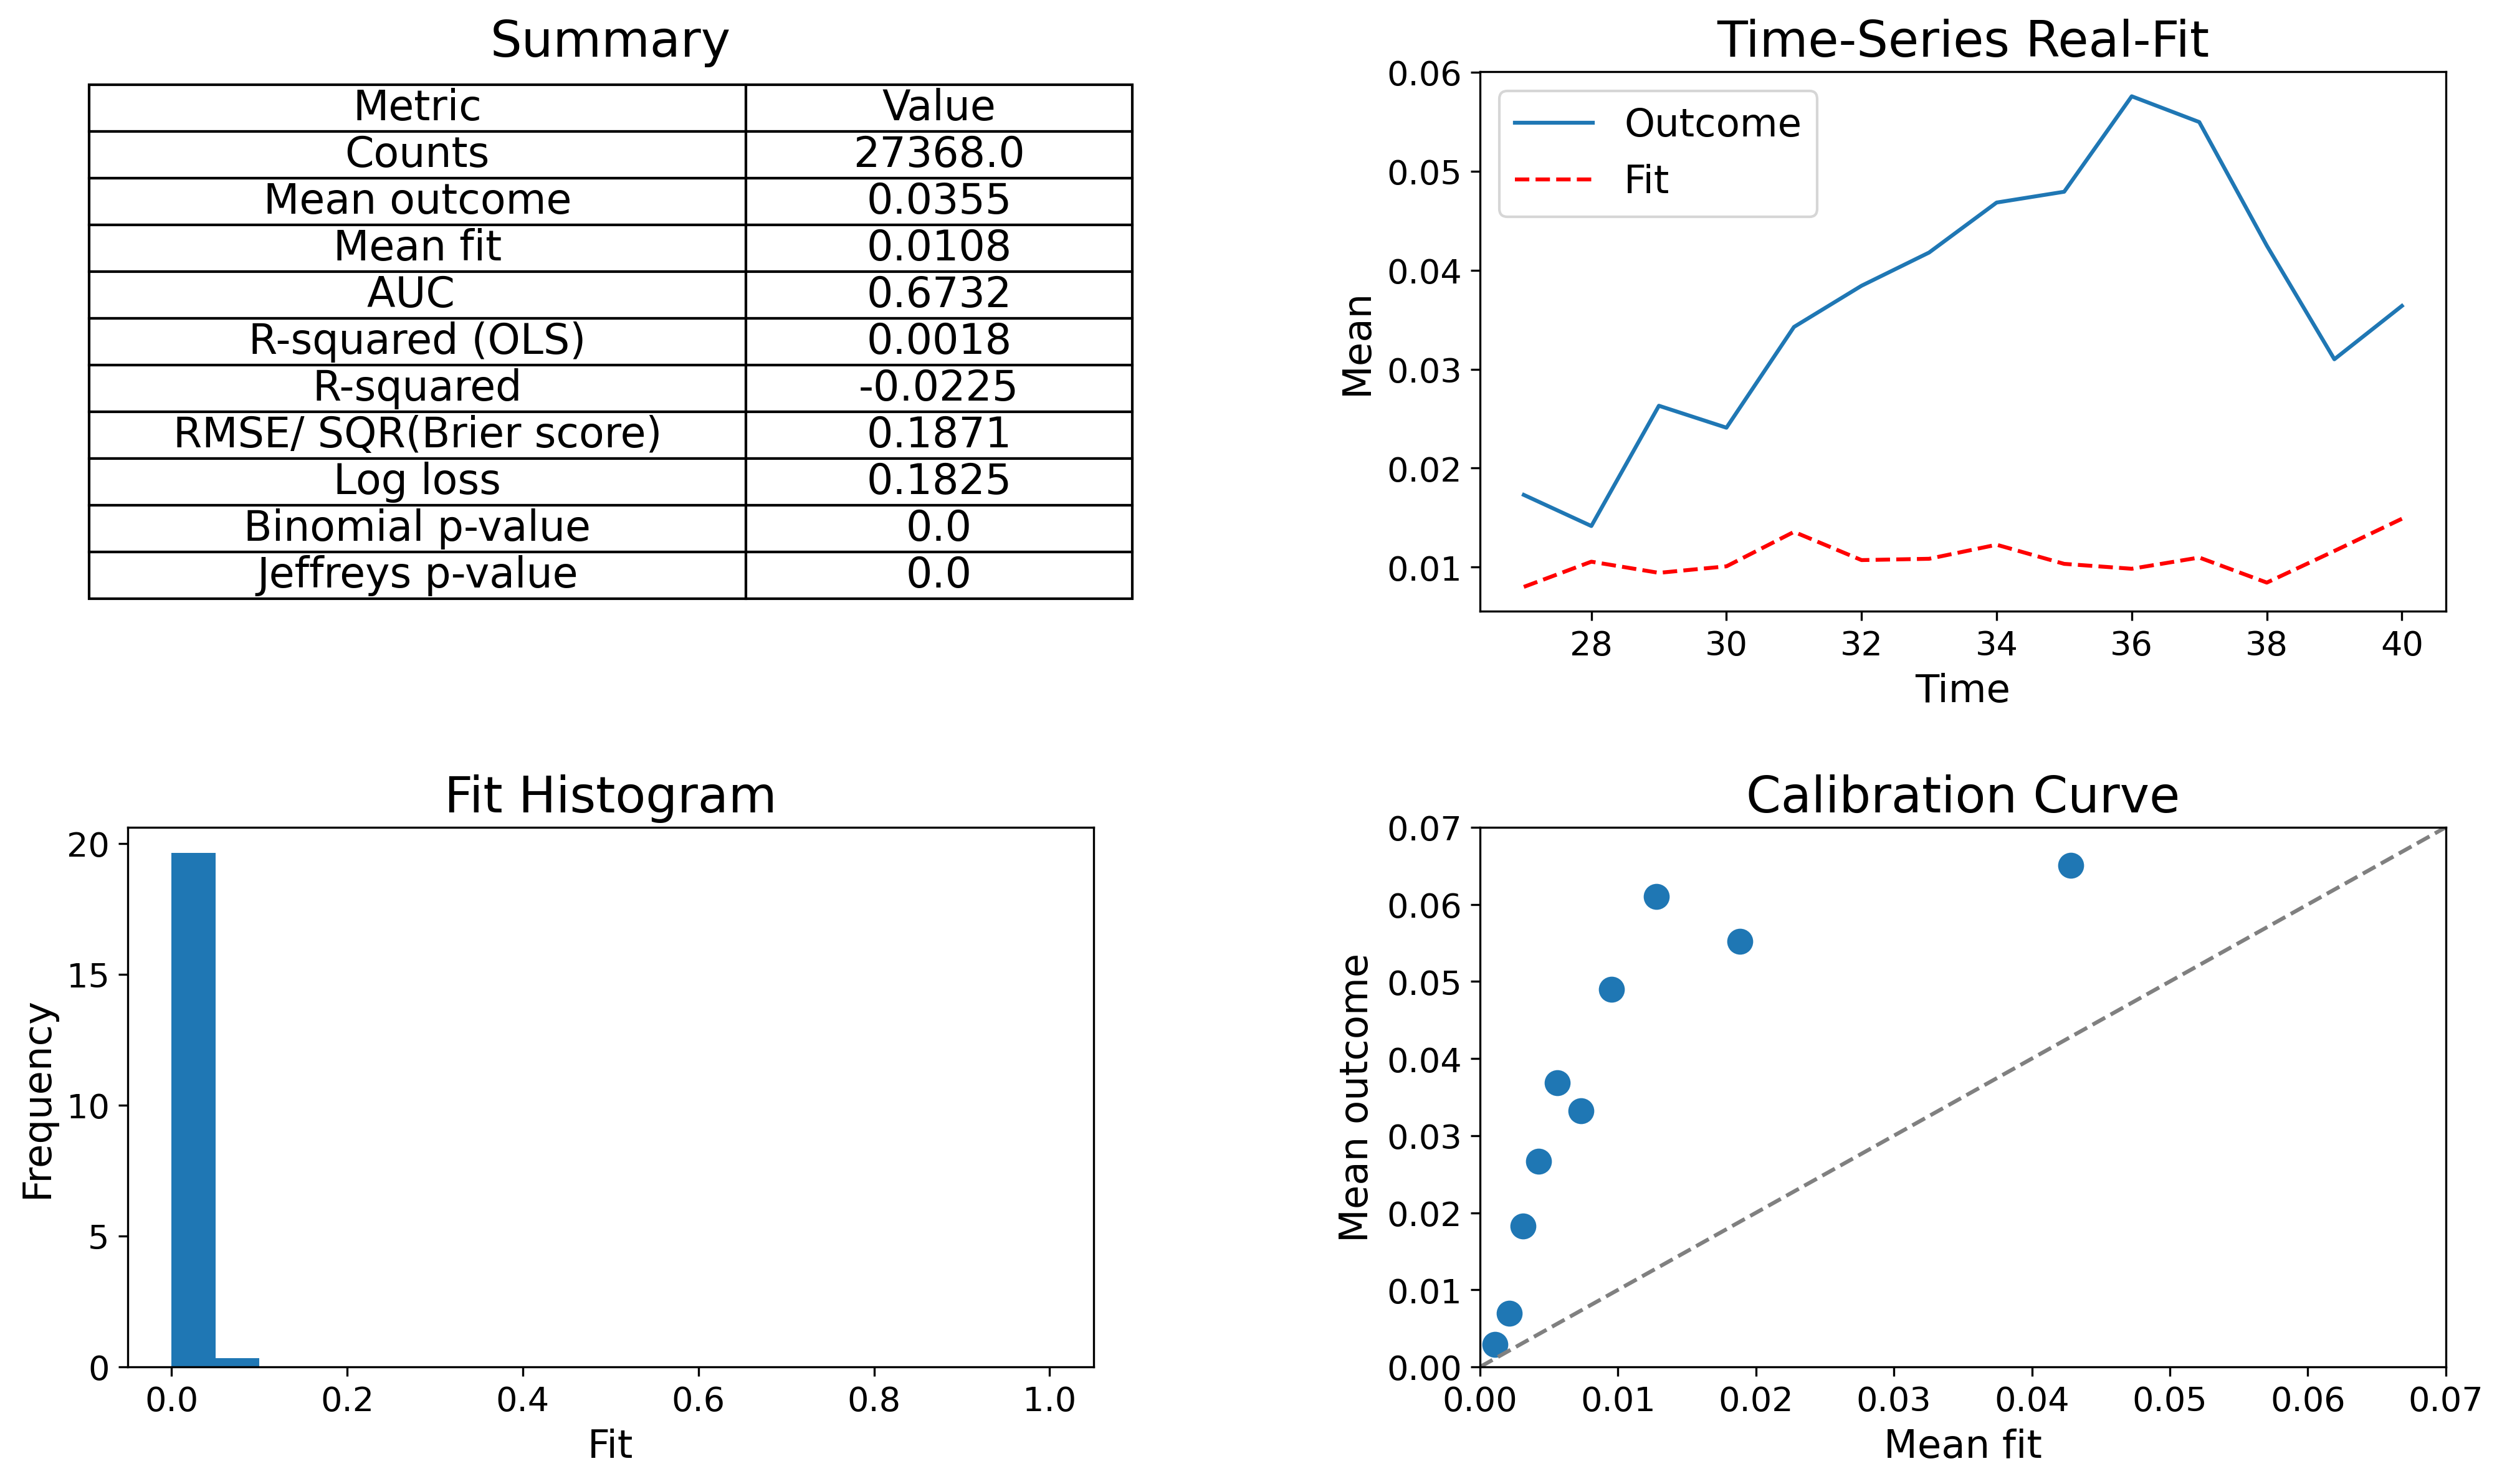

In [48]:
predictions_test = model_lr1.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test.loc[:,'time'].values)  

In [49]:
model_lr2 = LogisticRegression(penalty='l1', fit_intercept=True, C=0.1, solver='saga', tol=1e-15, max_iter=1000)  
model_lr2.fit(X_train_scaled, y_train) 
print(model_lr2.coef_.round(decimals=4))  
print(model_lr2.intercept_.round(decimals=4)) 

[[-0.0763 -0.1403  0.2736 -0.6955  0.      0.      0.      0.      0.
  -0.0118  0.    ]]
[-4.9579]


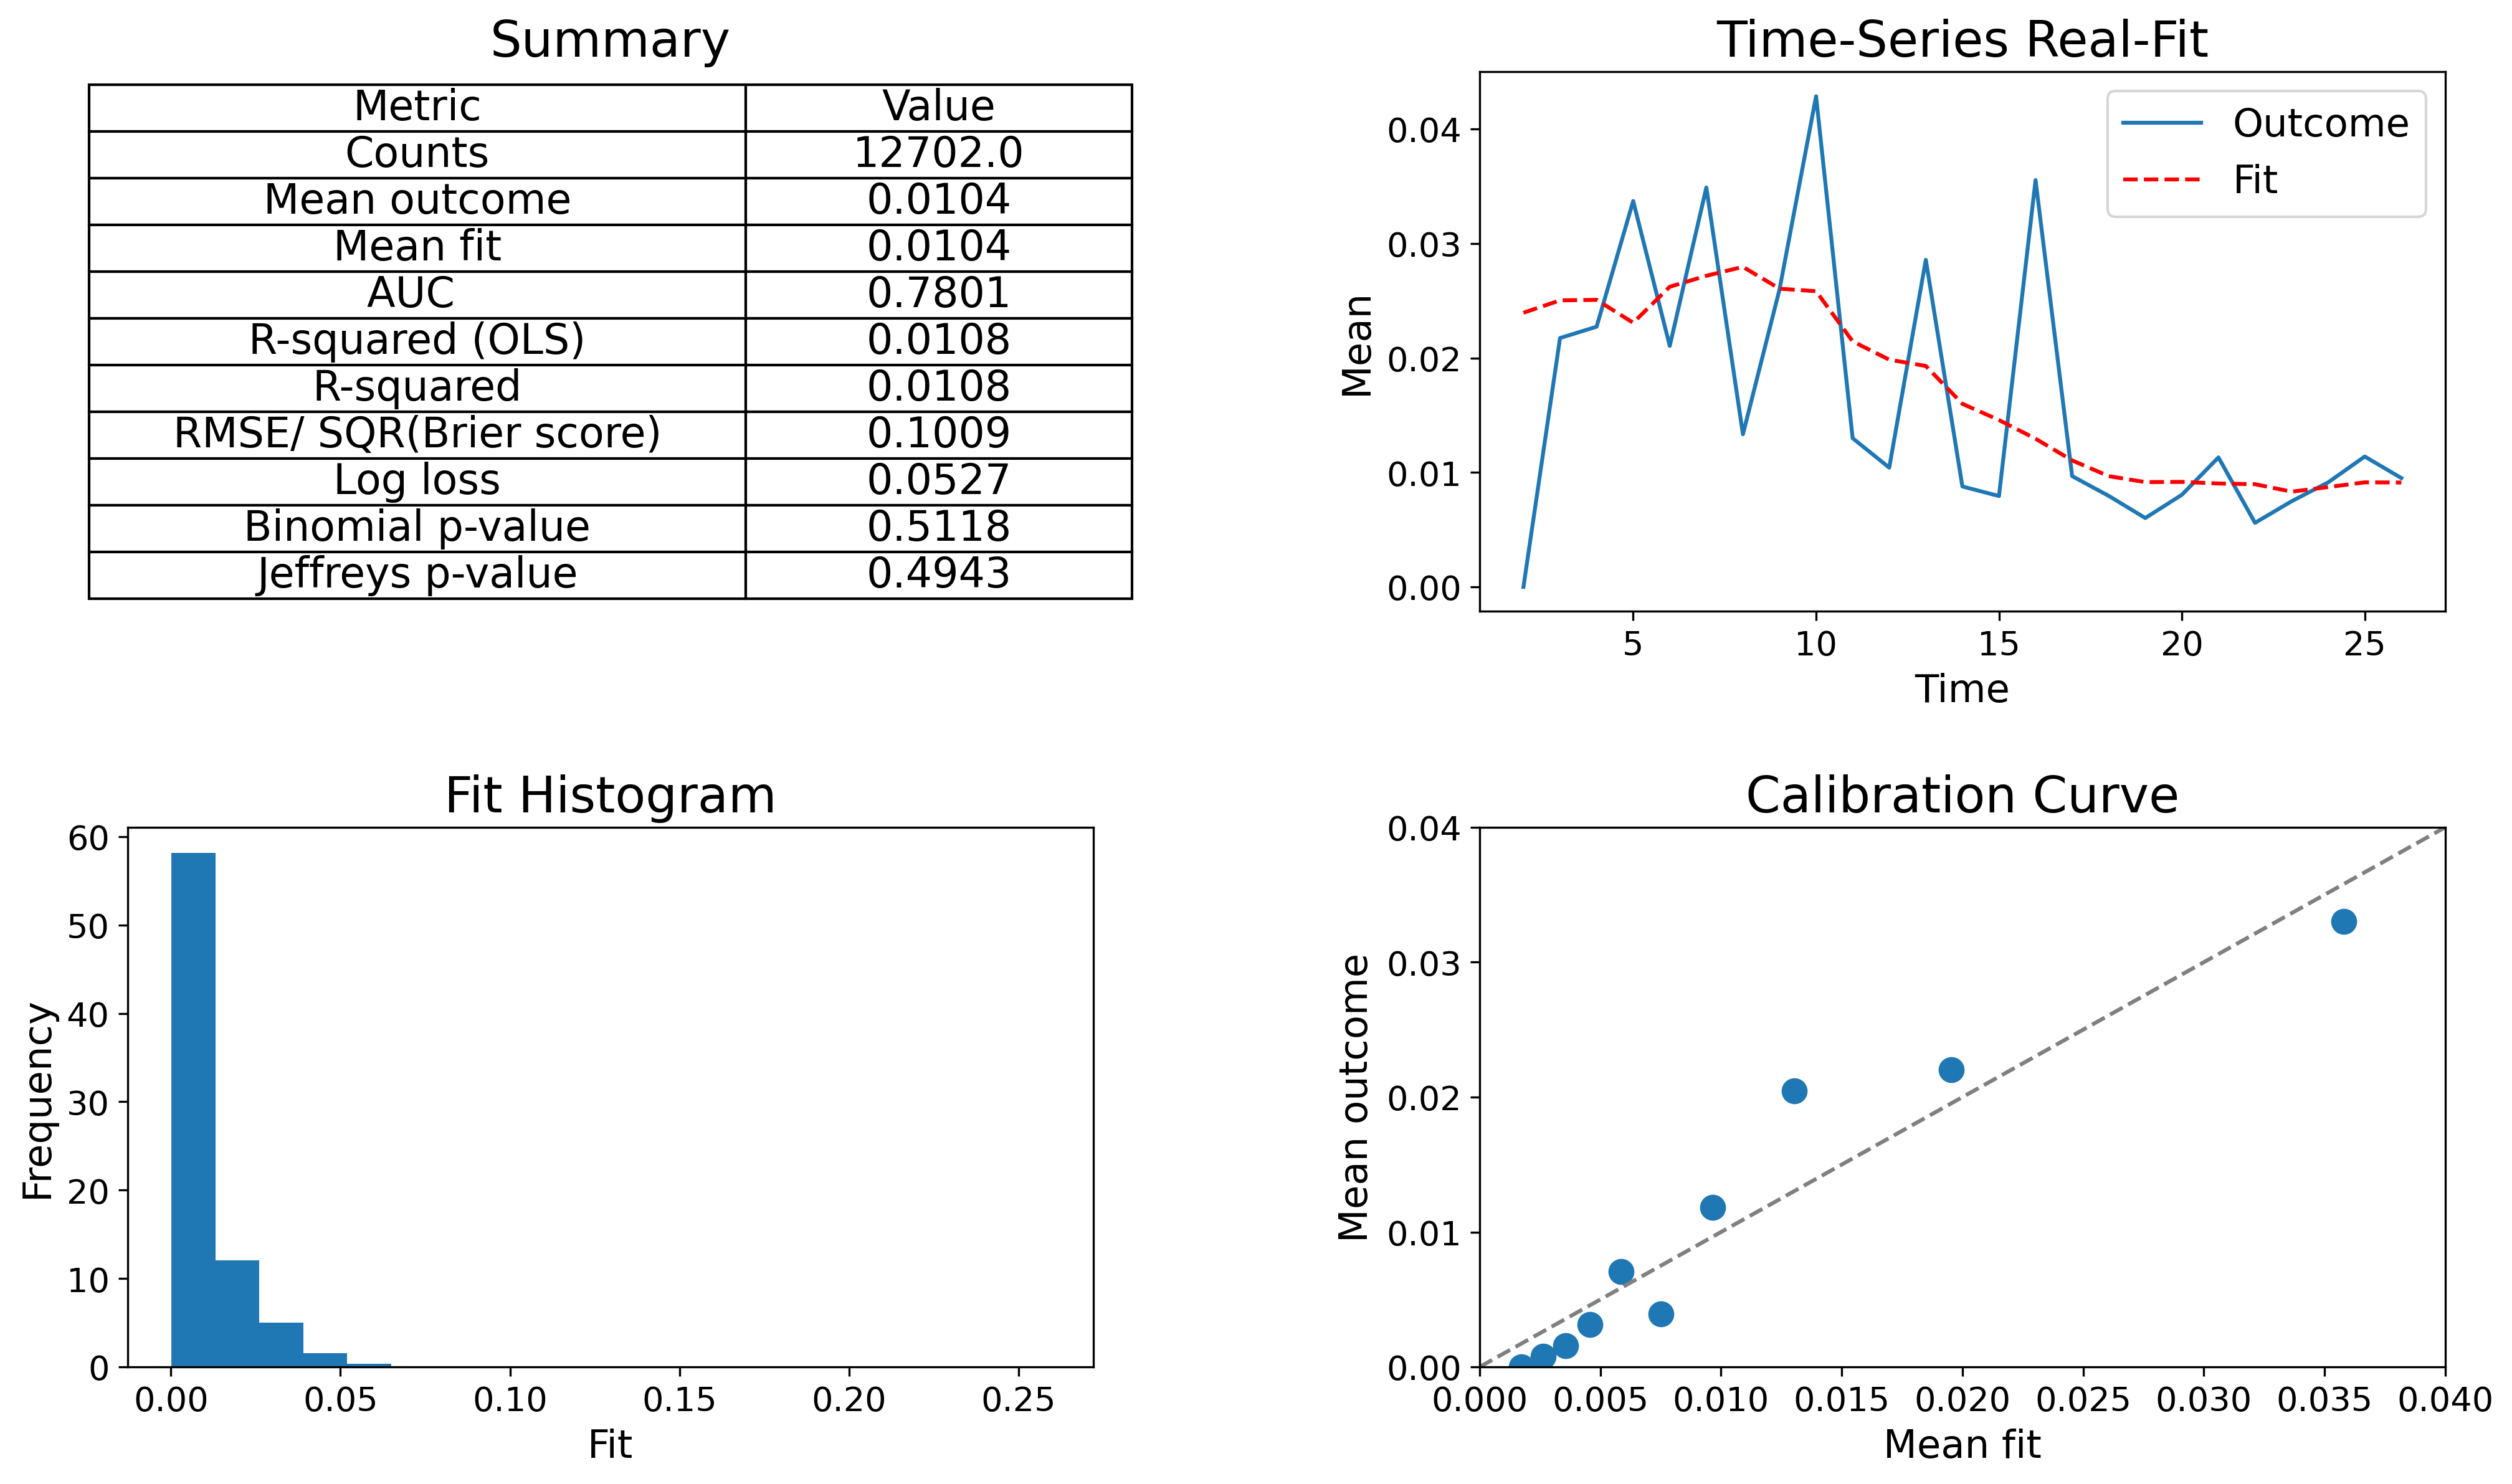

In [50]:
predictions_train = model_lr2.predict_proba(X_train_scaled)[:,1].T  
validation(predictions_train, y_train, data_train.loc[:,'time'].values) 


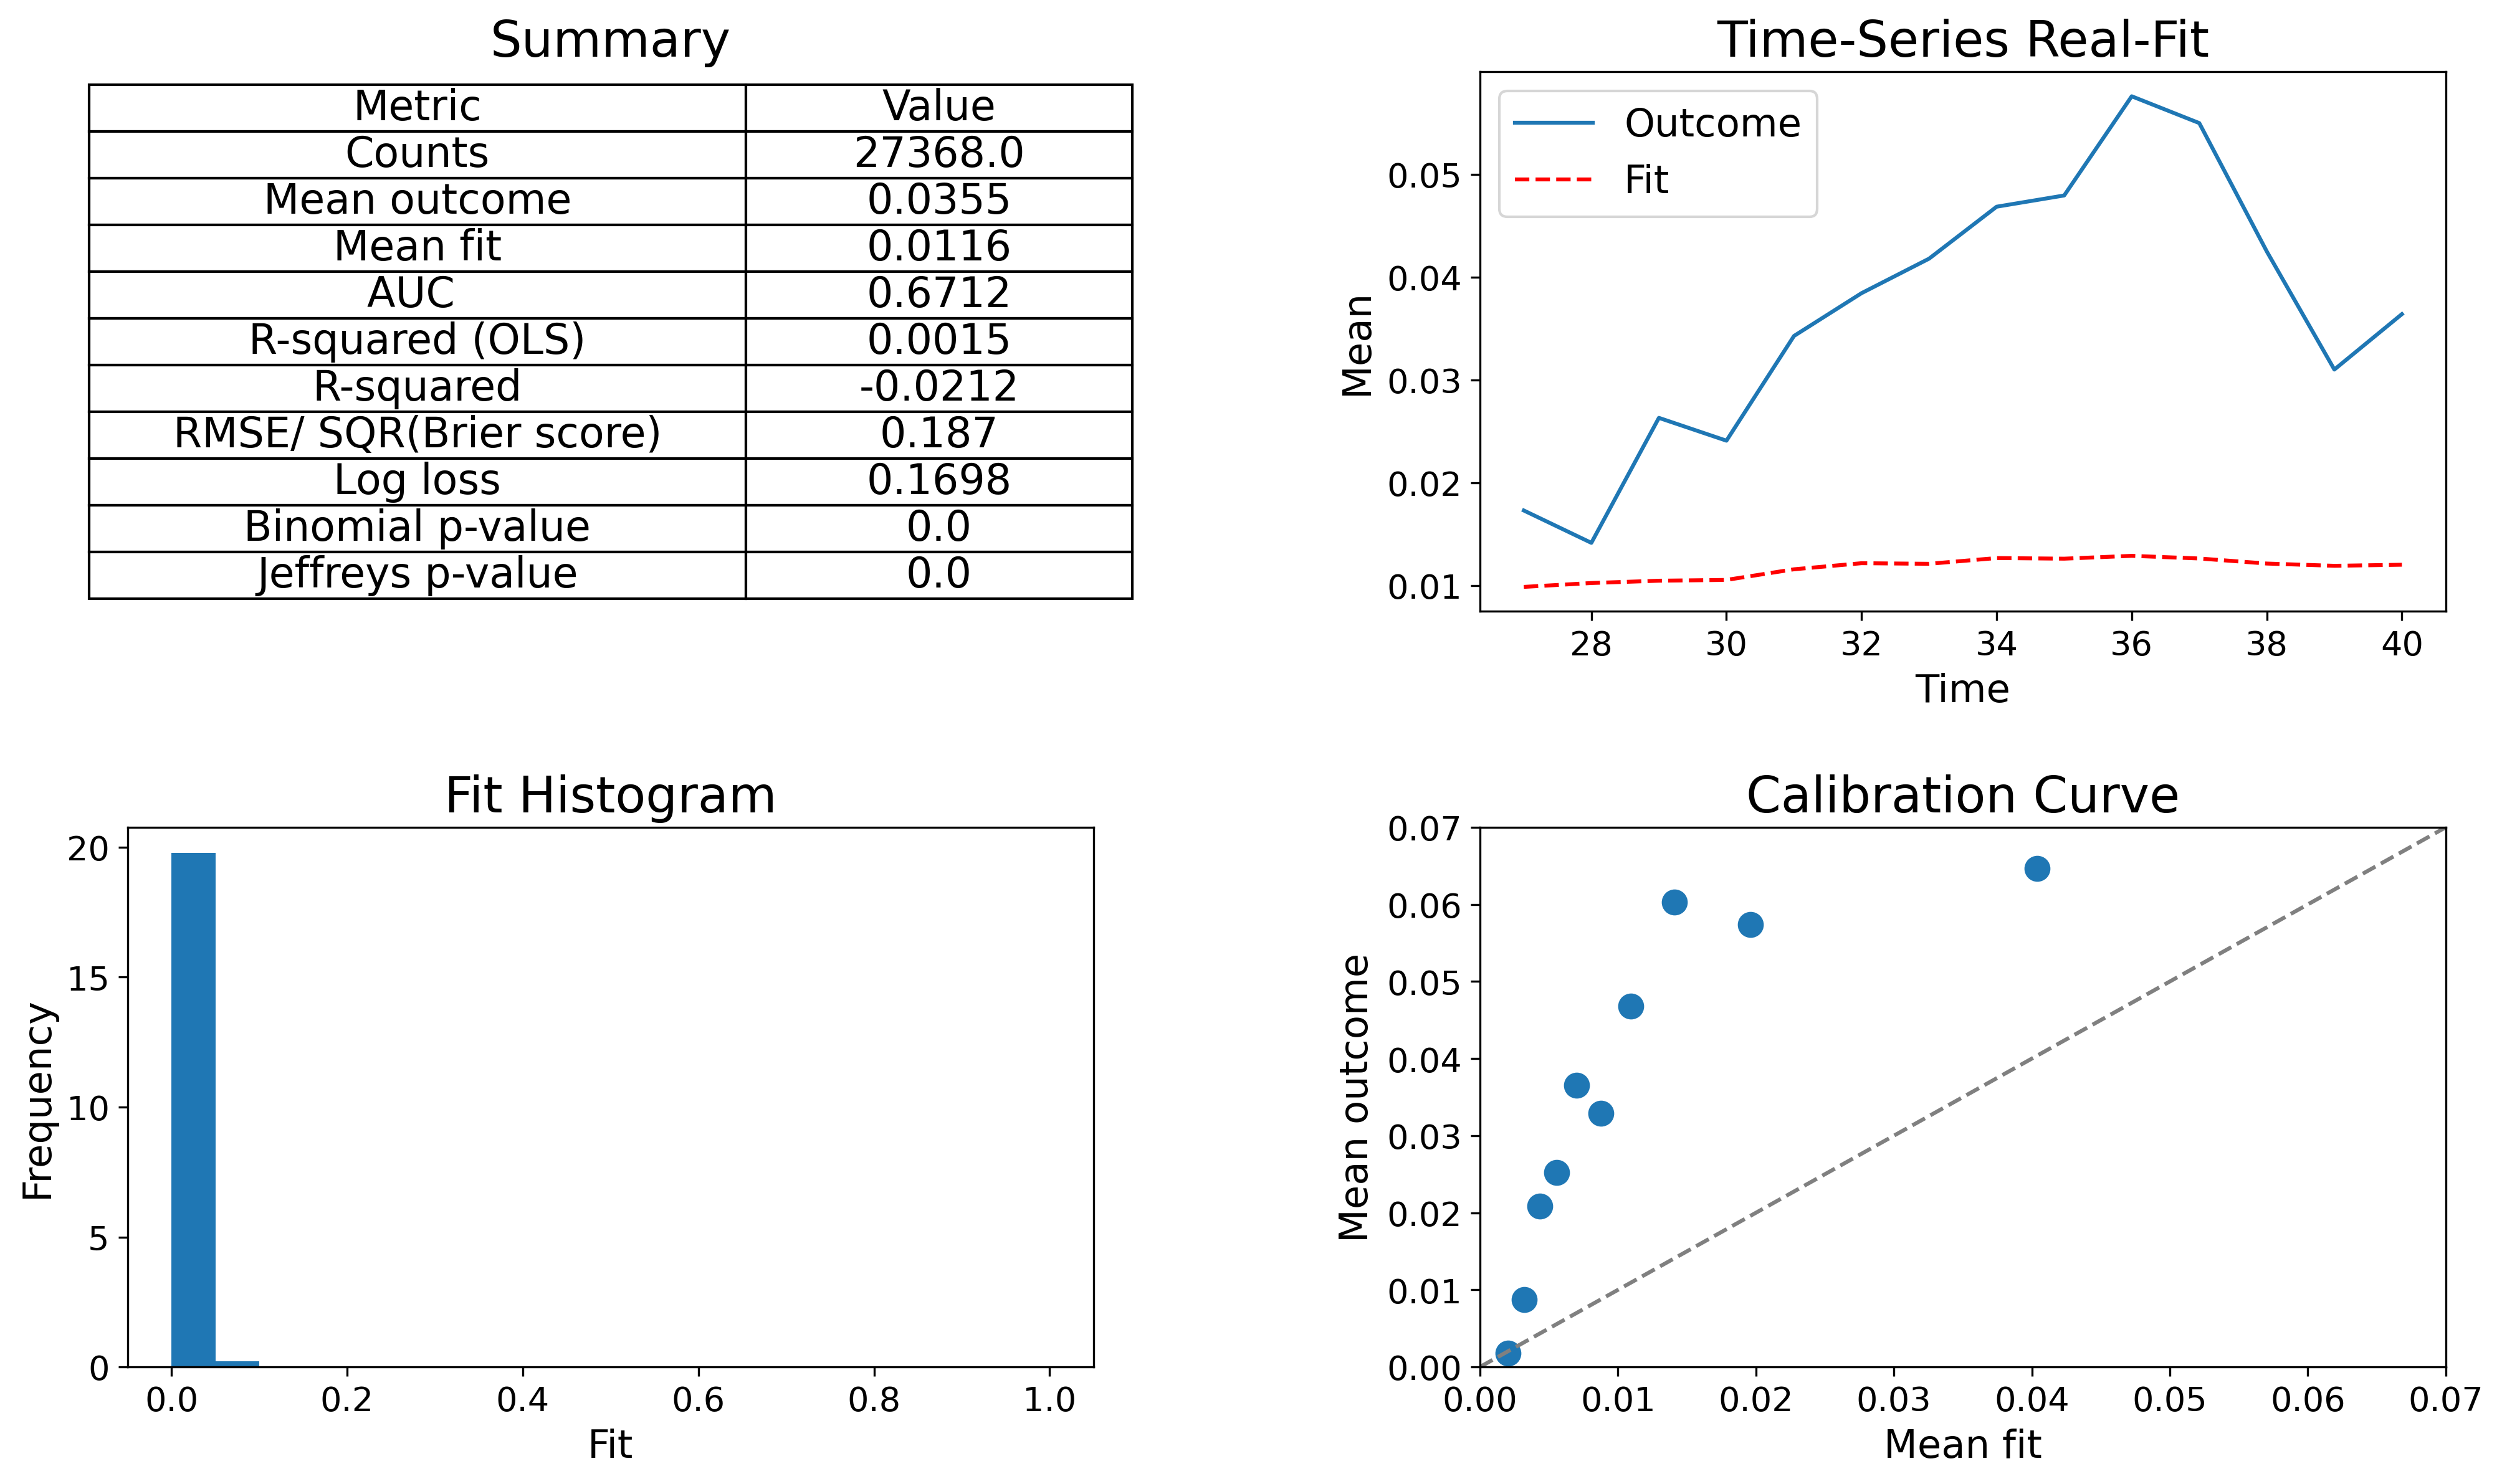

In [51]:
predictions_test = model_lr2.predict_proba(X_test_scaled)[:,1].T  
validation(predictions_test, y_test, data_test.loc[:,'time'].values)  

AUC (Model 1): 0.6732
AUC (Model 2): 0.6712


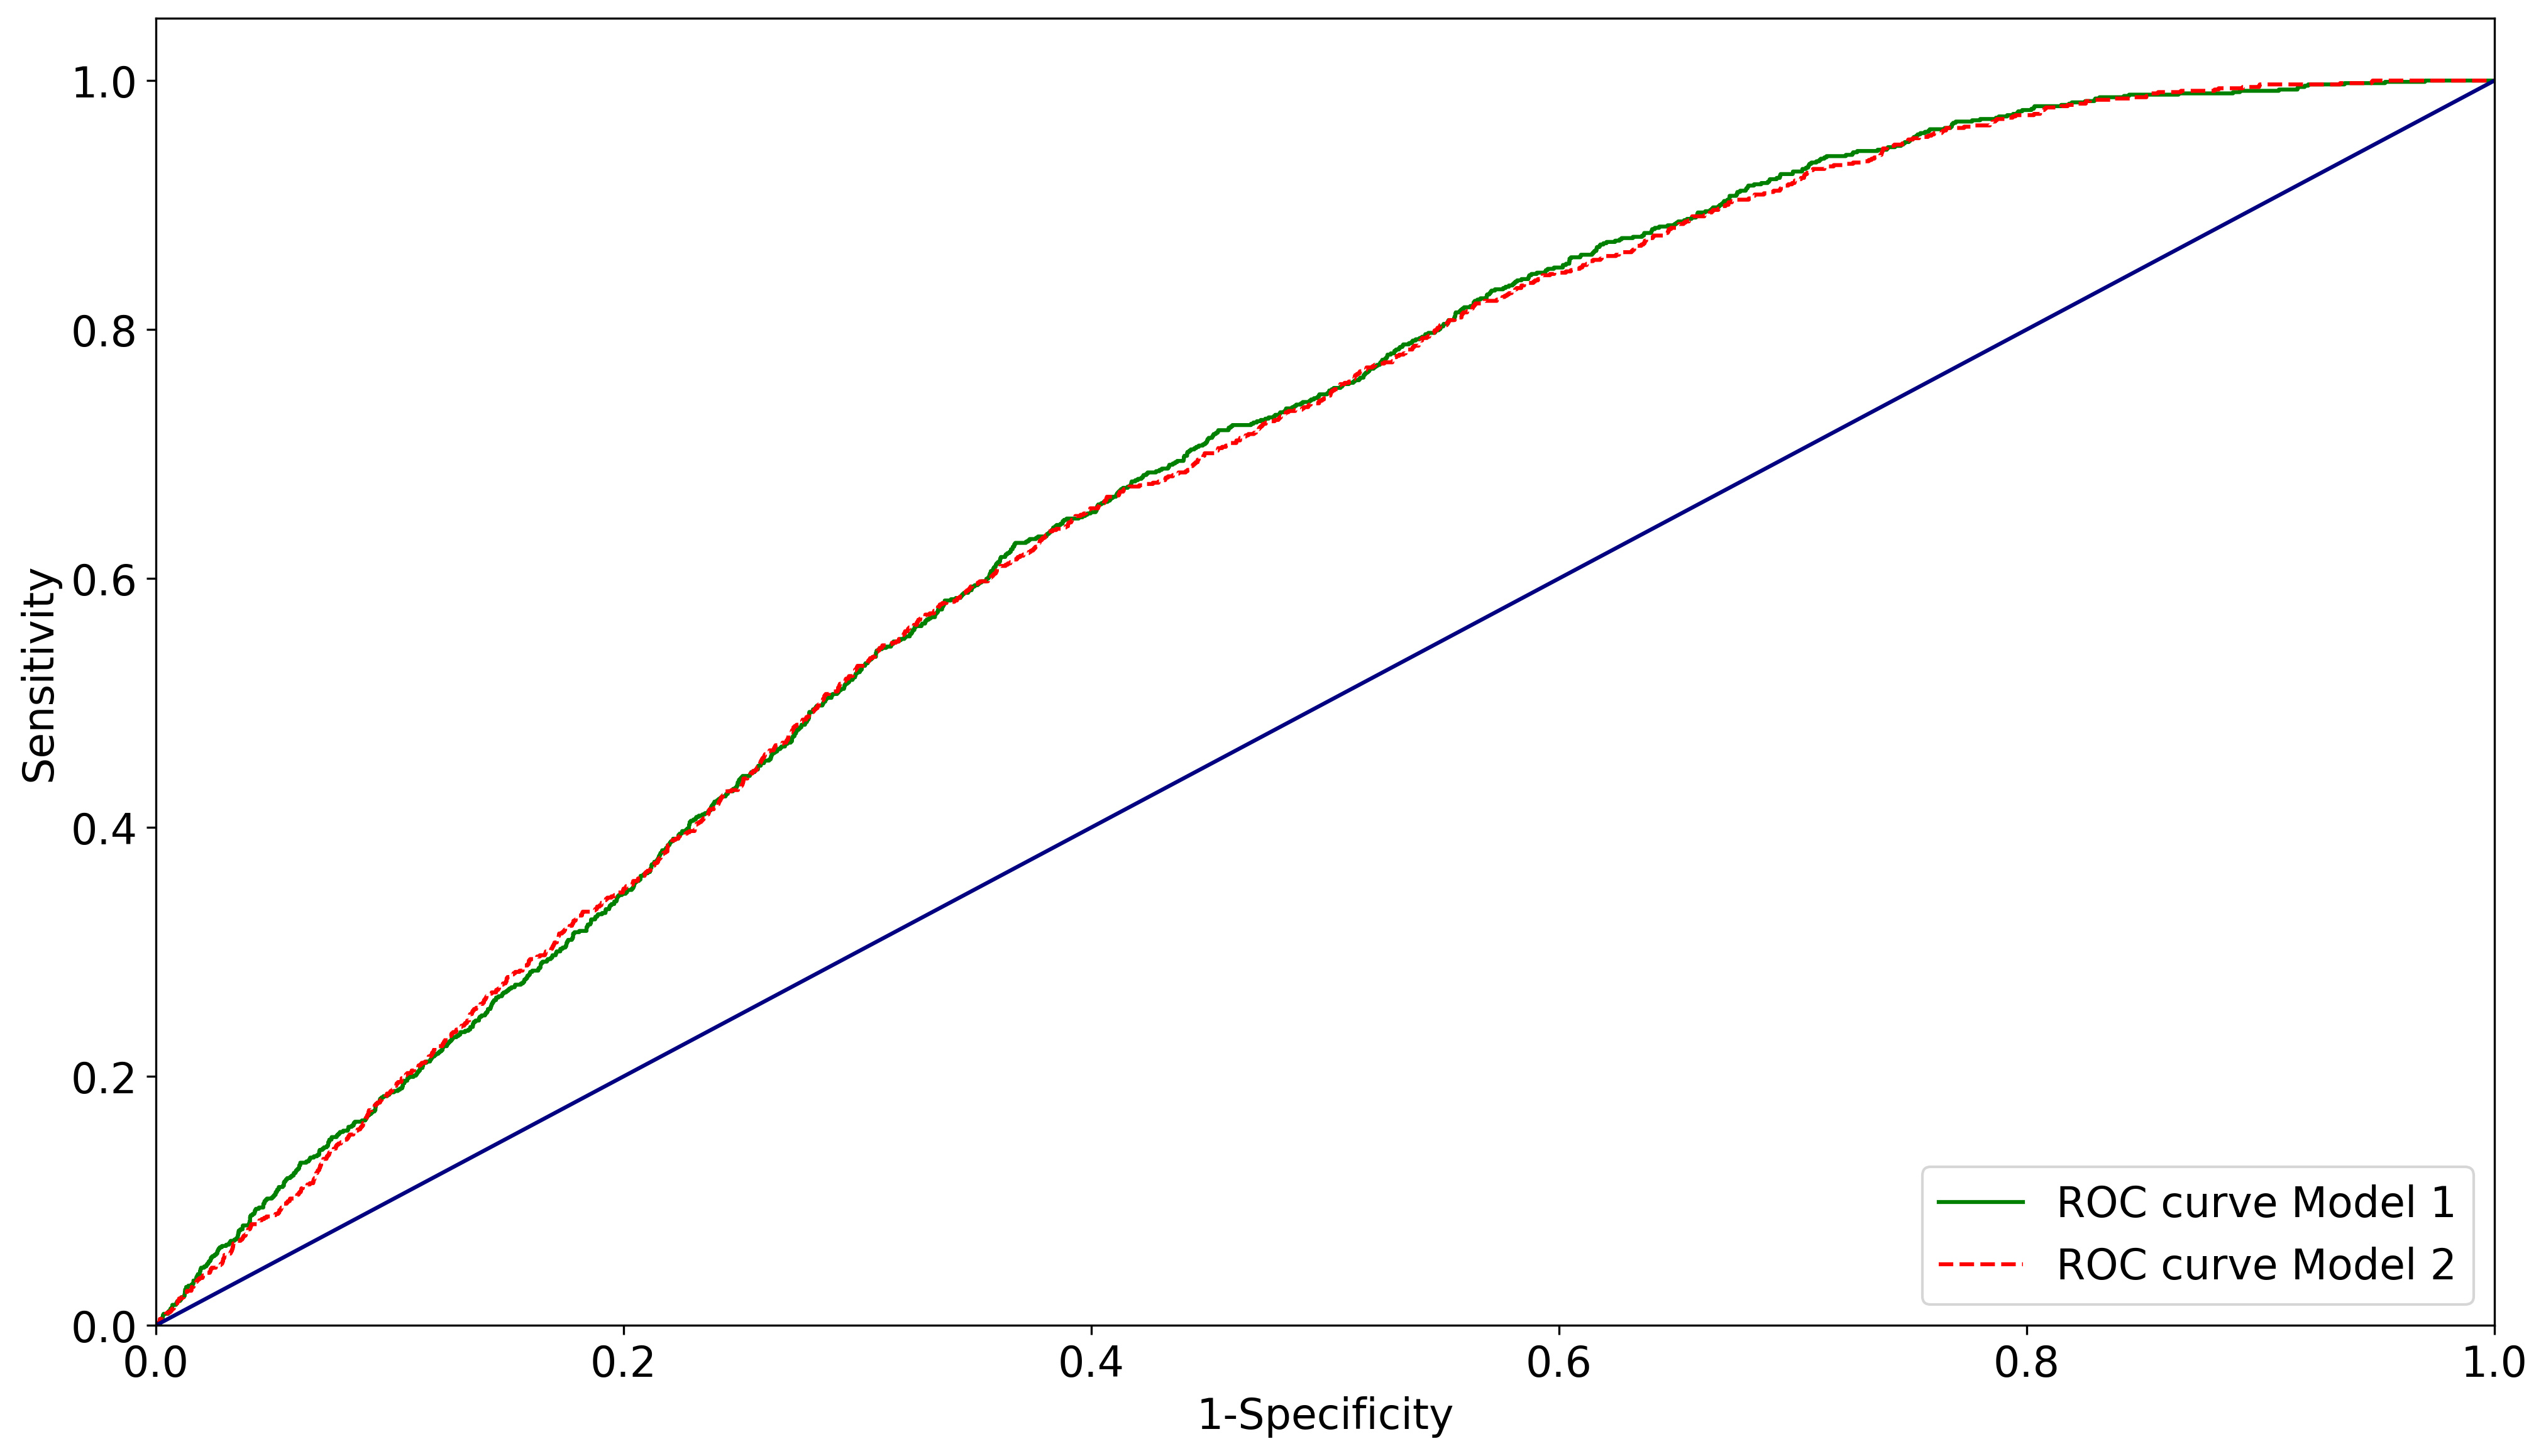

In [53]:
predictions_logit1 = model_lr1.predict_proba(X_test_scaled)[:,1].T  
predictions_logit2 = model_lr2.predict_proba(X_test_scaled)[:,1].T  
fpr1, tpr1, thresholds1 = roc_curve(y_test, predictions_logit1)  
roc_auc1 = roc_auc_score(y_test, predictions_logit1)  

print('AUC (Model 1):', roc_auc1.round(decimals=4))  


fpr2, tpr2, thresholds2 = roc_curve(y_test, predictions_logit2) 
roc_auc2 = roc_auc_score(y_test, predictions_logit2)

print('AUC (Model 2):', roc_auc2.round(decimals=4))  


plt.figure() 
plt.plot(fpr1, tpr1, color='green', label='ROC curve Model 1', linestyle='-')  
plt.plot(fpr2, tpr2, color='red', label='ROC curve Model 2', linestyle='--')  
plt.plot([0, 1], [0, 1], color='navy', linestyle='-')  
plt.xlim([0.0, 1.0])  
plt.ylim([0.0, 1.05])  
plt.ylabel('Sensitivity')  
plt.xlabel('1-Specificity') 
plt.legend(loc="lower right")  
plt.show() 


In [54]:
data_pdstab = data[['default_time', 'time', 'hpi_time']].copy() 
data_pdstab.loc[: ,'time_dummy'] = np.where(data_pdstab['time']>26, 1, 0) & np.where(  data_pdstab['time']<=40, 1, 0) 
data_pdstab.loc[: ,'interact_hpi'] = data_pdstab['hpi_time'] * data_pdstab['time_dummy'] 
print(data_pdstab.head().round(decimals=2)) 

   default_time  time  hpi_time  time_dummy  interact_hpi
0             0    25    226.29           0          0.00
1             0    26    225.10           0          0.00
2             0    27    222.39           1        222.39
3             0    28    219.67           1        219.67
4             0    29    217.37           1        217.37


In [55]:
X = data_pdstab[['hpi_time', 'interact_hpi', 'time_dummy']] 
y = data_pdstab['default_time'].values.reshape(-1,)  
X_logit = sm.add_constant(X, prepend=False)  
logit_model = sm.Logit(y, X_logit).fit()  
print(logit_model.summary()) 

Optimization terminated successfully.
         Current function value: 0.121318
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                41955
Model:                          Logit   Df Residuals:                    41951
Method:                           MLE   Df Model:                            3
Date:                Mon, 04 Aug 2025   Pseudo R-squ.:                 0.03295
Time:                        17:24:43   Log-Likelihood:                -5089.9
converged:                       True   LL-Null:                       -5263.3
Covariance Type:            nonrobust   LLR p-value:                 7.163e-75
                   coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------
hpi_time        -0.0086      0.002     -3.496      0.000      -0.013      -0.004
interact_hpi    -0.0039

In [56]:
def PD_fun(HPI):  
    linpred1 = -2.7905 -0.0086 * HPI  
    linpred2 = -1.0307 - 0.0125 * HPI  
    PD1 = np.exp(linpred1)/ (1+np.exp(linpred1))
    PD2 = np.exp(linpred2)/ (1+np.exp(linpred2)) 
    return PD1, PD2 


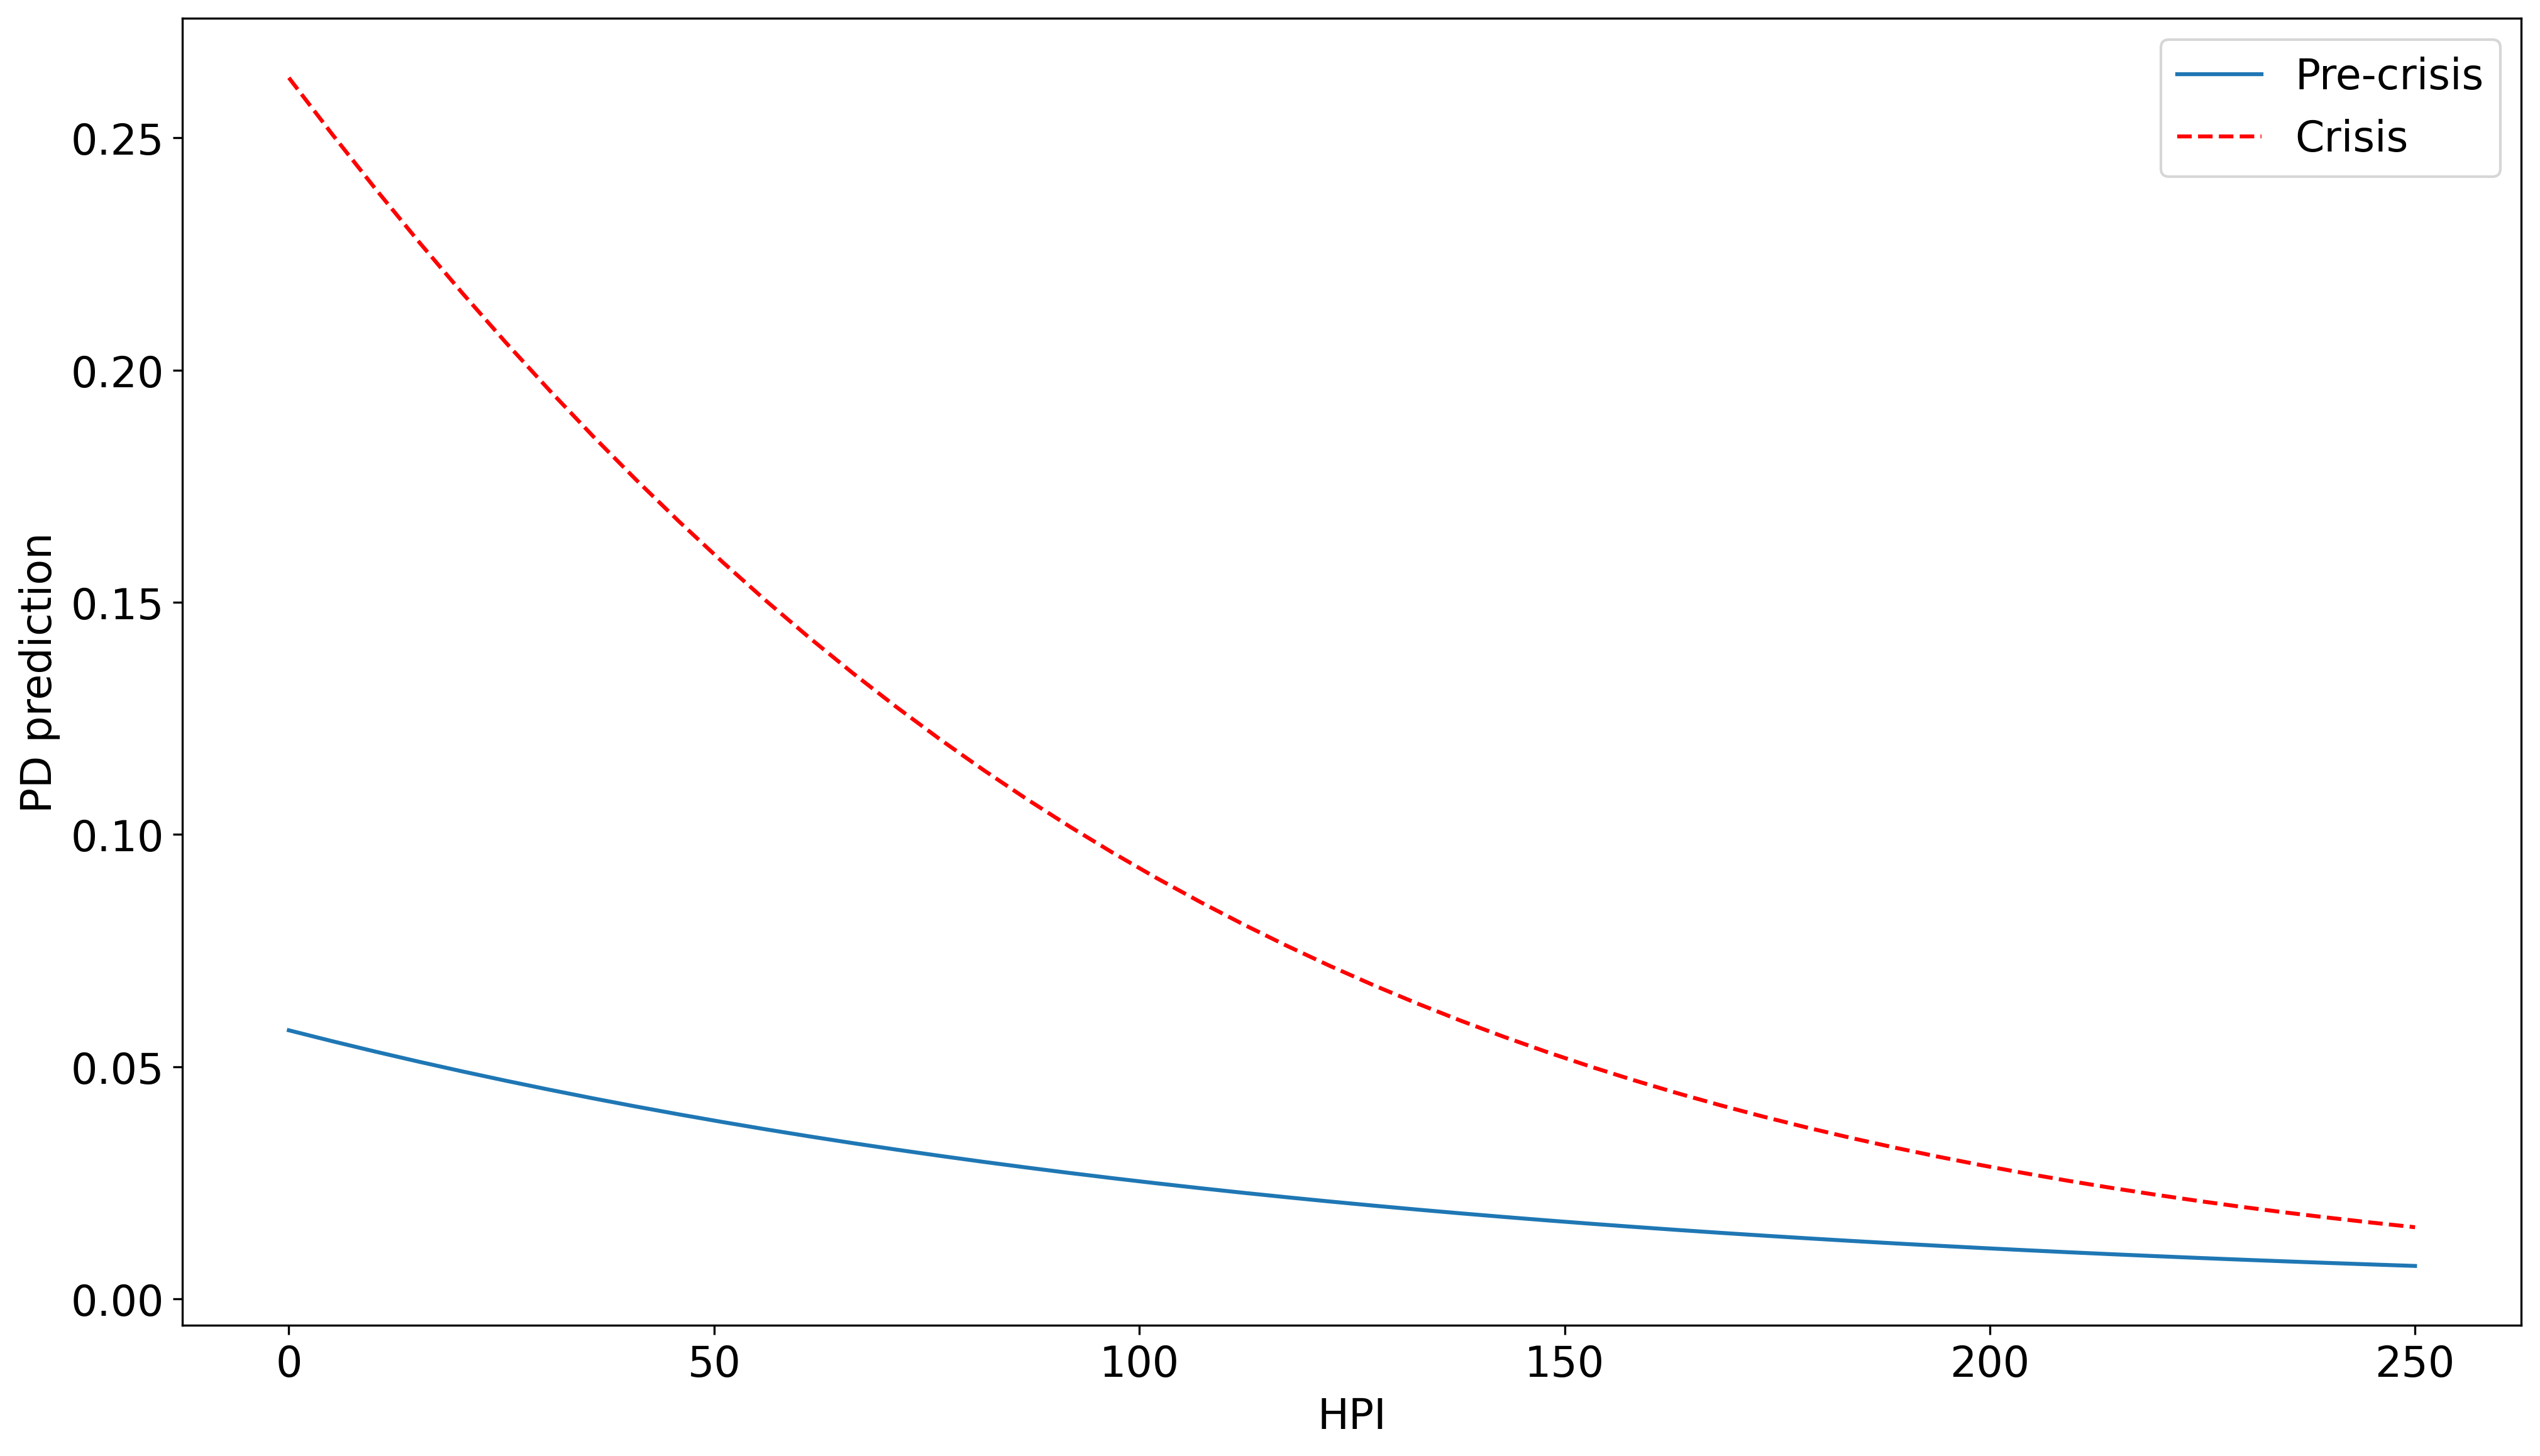

In [57]:
x = np.linspace(0, 250, 50) 
HPI = x  
PD_pred = PD_fun(HPI) 

plt.plot(HPI, PD_pred[0], label='Pre-crisis')  
plt.plot(HPI, PD_pred[1], color='red', label='Crisis', linestyle='--') 
plt.ylabel('PD prediction') 
plt.xlabel('HPI') 
plt.legend(loc="best")  
plt.show()  